<a href="https://colab.research.google.com/github/Jamila-Hanif/Predicting-Covid-19-using-Machine-Learning-Models/blob/main/COVID_19_positive_negative_cases_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# libaries
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
from sklearn.ensemble import StackingClassifier


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/ML covid-19 /dataset 2.xlsx')

In [ ]:
try:
    df = pd.read_excel('/content/drive/MyDrive/ML covid-19 /dataset 2.xlsx')
except FileNotFoundError:
    print("Error: Dataset file not found.")
except Exception as e:
    print(f"An error occurred: {e}")


In [ ]:
pd.read_excel('/content/drive/MyDrive/ML covid-19 /dataset 2.xlsx')

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.022340,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5639,ae66feb9e4dc3a0,3,positive,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5640,517c2834024f3ea,17,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5641,5c57d6037fe266d,4,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5642,c20c44766f28291,10,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.head()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
0,44477f75e8169d2,13,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,126e9dd13932f68,17,negative,0,0,0,0.236515,-0.02234,-0.517413,0.010677,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,a46b4402a0e5696,8,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,f7d619a94f97c45,5,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,d9e41465789c2b5,15,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.tail()

,Patient ID,Patient age quantile,SARS-Cov-2 exam result,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
5639,ae66feb9e4dc3a0,3,positive,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5640,517c2834024f3ea,17,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5641,5c57d6037fe266d,4,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5642,c20c44766f28291,10,negative,0,0,0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5643,2697fdccbfeb7f7,19,positive,0,0,0,0.694287,0.541564,-0.906829,-0.325903,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.describe()

,Patient age quantile,"Patient addmited to regular ward (1=yes, 0=no)","Patient addmited to semi-intensive unit (1=yes, 0=no)","Patient addmited to intensive care unit (1=yes, 0=no)",Hematocrit,Hemoglobin,Platelets,Mean platelet volume,Red blood Cells,Lymphocytes,...,Hb saturation (arterial blood gases),pCO2 (arterial blood gas analysis),Base excess (arterial blood gas analysis),pH (arterial blood gas analysis),Total CO2 (arterial blood gas analysis),HCO3 (arterial blood gas analysis),pO2 (arterial blood gas analysis),Arteiral Fio2,Phosphor,ctO2 (arterial blood gas analysis)
count,5644.000000,5644.000000,5644.000000,5644.000000,6.030000e+02,6.030000e+02,6.020000e+02,5.990000e+02,6.020000e+02,6.020000e+02,...,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.700000e+01,2.000000e+01,2.000000e+01,2.700000e+01
mean,9.318391,0.013997,0.008859,0.007264,-2.186214e-09,-1.601319e-08,-3.535004e-10,7.438142e-09,8.424447e-09,-7.866736e-09,...,-1.379737e-10,8.416397e-09,-1.655685e-09,4.139211e-10,-7.472139e-09,6.070843e-09,-2.469729e-08,4.656613e-09,6.332993e-09,5.243001e-09
std,5.777903,0.117489,0.093713,0.084929,1.000830e+00,1.000830e+00,1.000832e+00,1.000836e+00,1.000832e+00,1.000832e+00,...,1.019049e+00,1.019049e+00,1.019049e+00,1.019049e+00,1.019049e+00,1.019049e+00,1.019049e+00,1.025978e+00,1.025978e+00,1.019049e+00
min,0.000000,0.000000,0.000000,0.000000,-4.501420e+00,-4.345603e+00,-2.552426e+00,-2.457575e+00,-3.970608e+00,-1.865070e+00,...,-1.999560e+00,-1.244817e+00,-3.082674e+00,-3.568877e+00,-2.925618e+00,-2.985592e+00,-1.175907e+00,-1.532932e+00,-1.480526e+00,-2.900254e+00
25%,4.000000,0.000000,0.000000,0.000000,-5.188074e-01,-5.862439e-01,-6.053457e-01,-6.624832e-01,-5.679496e-01,-7.307069e-01,...,-1.122574e+00,-5.348102e-01,-3.308668e-01,-9.210583e-02,-5.117720e-01,-5.397211e-01,-8.169898e-01,-1.214975e-01,-5.527296e-01,-4.852787e-01
50%,9.000000,0.000000,0.000000,0.000000,5.340703e-02,4.031596e-02,-1.217160e-01,-1.015171e-01,1.385207e-02,-1.426696e-02,...,2.677689e-01,-2.120799e-01,-1.181667e-02,2.942021e-01,7.743482e-02,5.633191e-02,-1.599549e-01,-1.174366e-02,-1.381825e-01,1.826928e-01
75%,14.000000,0.000000,0.000000,0.000000,7.171751e-01,7.295320e-01,5.314981e-01,6.838353e-01,6.661759e-01,5.976919e-01,...,7.383496e-01,2.305214e-02,6.661649e-01,5.115003e-01,4.385609e-01,5.085100e-01,4.500090e-01,-1.174366e-02,2.763648e-01,5.937525e-01
max,19.000000,1.000000,1.000000,1.000000,2.662704e+00,2.671868e+00,9.532034e+00,3.713052e+00,3.645706e+00,3.764100e+00,...,1.337265e+00,3.236524e+00,1.703078e+00,1.042674e+00,1.940087e+00,2.029471e+00,2.205371e+00,2.841856e+00,2.862350e+00,1.826932e+00


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5644 entries, 0 to 5643
Columns: 111 entries, Patient ID to ctO2 (arterial blood gas analysis)
dtypes: float64(70), int64(4), object(37)
memory usage: 4.8+ MB


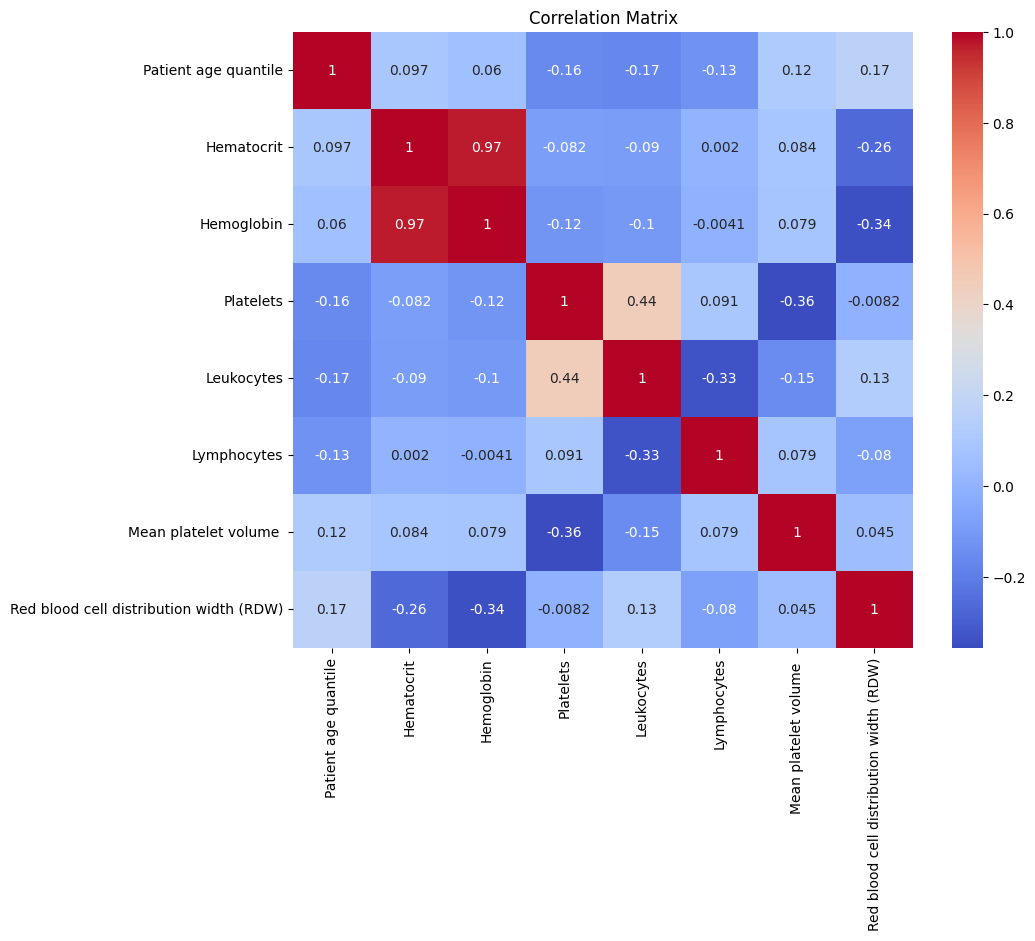

In [ ]:
# Correlation matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Define the features list before using it
features = [
    'Patient age quantile',  # Demographic information
    'Hematocrit',
    'Hemoglobin',
    'Platelets',
    'Leukocytes',
    'Lymphocytes',
    'Mean platelet volume ',
    'Red blood cell distribution width (RDW)',
]

correlation_matrix = df[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [ ]:
#Check for missing values
print(df.isnull().sum())

Patient ID                                                  0
Patient age quantile                                        0
SARS-Cov-2 exam result                                      0
Patient addmited to regular ward (1=yes, 0=no)              0
Patient addmited to semi-intensive unit (1=yes, 0=no)       0
                                                         ... 
HCO3 (arterial blood gas analysis)                       5617
pO2 (arterial blood gas analysis)                        5617
Arteiral Fio2                                            5624
Phosphor                                                 5624
ctO2 (arterial blood gas analysis)                       5617
Length: 111, dtype: int64


In [ ]:
print(df.columns)

Index(['Patient ID', 'Patient age quantile', 'SARS-Cov-2 exam result',
       'Patient addmited to regular ward (1=yes, 0=no)',
       'Patient addmited to semi-intensive unit (1=yes, 0=no)',
       'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ',
       ...
       'Hb saturation (arterial blood gases)',
       'pCO2 (arterial blood gas analysis)',
       'Base excess (arterial blood gas analysis)',
       'pH (arterial blood gas analysis)',
       'Total CO2 (arterial blood gas analysis)',
       'HCO3 (arterial blood gas analysis)',
       'pO2 (arterial blood gas analysis)', 'Arteiral Fio2', 'Phosphor',
       'ctO2 (arterial blood gas analysis)'],
      dtype='object', length=111)


In [ ]:
# Calculate percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Print columns with missing values above a threshold (e.g., 50%)
for column, percentage in missing_percentage.items():
    if percentage > 50:  # Set your desired threshold
        print(f"Column '{column}' has {percentage:.2f}% missing values.")

Column 'Hematocrit' has 89.32% missing values.
Column 'Hemoglobin' has 89.32% missing values.
Column 'Platelets' has 89.33% missing values.
Column 'Mean platelet volume ' has 89.39% missing values.
Column 'Red blood Cells' has 89.33% missing values.
Column 'Lymphocytes' has 89.33% missing values.
Column 'Mean corpuscular hemoglobin concentration (MCHC)' has 89.33% missing values.
Column 'Leukocytes' has 89.33% missing values.
Column 'Basophils' has 89.33% missing values.
Column 'Mean corpuscular hemoglobin (MCH)' has 89.33% missing values.
Column 'Eosinophils' has 89.33% missing values.
Column 'Mean corpuscular volume (MCV)' has 89.33% missing values.
Column 'Monocytes' has 89.35% missing values.
Column 'Red blood cell distribution width (RDW)' has 89.33% missing values.
Column 'Serum Glucose' has 96.31% missing values.
Column 'Respiratory Syncytial Virus' has 76.01% missing values.
Column 'Influenza A' has 76.01% missing values.
Column 'Influenza B' has 76.01% missing values.
Column '

In [ ]:
# Impute missing values before dropping columns (Retain original columns)
imputer = SimpleImputer(strategy='mean')  # Or other strategy like 'median', 'most_frequent'

# Get the actual column names from the DataFrame
columns_to_impute = ['Hematocrit', 'Hemoglobin', 'Platelets', 'Leukocytes', 'Lymphocytes', 'Mean platelet volume ', 'Red blood cell distribution width (RDW)']
actual_columns = [col for col in columns_to_impute if col in df.columns]

# Impute missing values only for the columns that exist
if actual_columns:  # Check if any columns were found
    df[actual_columns] = imputer.fit_transform(df[actual_columns])
else:
    print("Warning: None of the specified columns were found in the DataFrame. Skipping imputation.")

In [ ]:
print(df.columns)

Index(['Patient ID', 'Patient age quantile', 'SARS-Cov-2 exam result',
       'Patient addmited to regular ward (1=yes, 0=no)',
       'Patient addmited to semi-intensive unit (1=yes, 0=no)',
       'Patient addmited to intensive care unit (1=yes, 0=no)', 'Hematocrit',
       'Hemoglobin', 'Platelets', 'Mean platelet volume ',
       ...
       'Hb saturation (arterial blood gases)',
       'pCO2 (arterial blood gas analysis)',
       'Base excess (arterial blood gas analysis)',
       'pH (arterial blood gas analysis)',
       'Total CO2 (arterial blood gas analysis)',
       'HCO3 (arterial blood gas analysis)',
       'pO2 (arterial blood gas analysis)', 'Arteiral Fio2', 'Phosphor',
       'ctO2 (arterial blood gas analysis)'],
      dtype='object', length=111)


In [ ]:
# data cleaning and processing
# Normalize column names in the DataFrame
df.columns = df.columns.str.strip()  # Remove leading/trailing spaces
df.columns = df.columns.str.lower()   # Convert to lowercase

# Adjust columns_to_impute to match normalized names
columns_to_impute = ['hematocrit', 'hemoglobin', 'platelets', 'leukocytes', 'lymphocytes', 'mean platelet volume ', 'red blood cell distribution width (rdw)']
actual_columns = [col for col in columns_to_impute if col in df.columns]

# Impute missing values only for the columns that exist
if actual_columns:  # Check if any columns were found
    df[actual_columns] = imputer.fit_transform(df[actual_columns])
else:
    print("Warning: None of the specified columns were found in the DataFrame. Skipping imputation.")

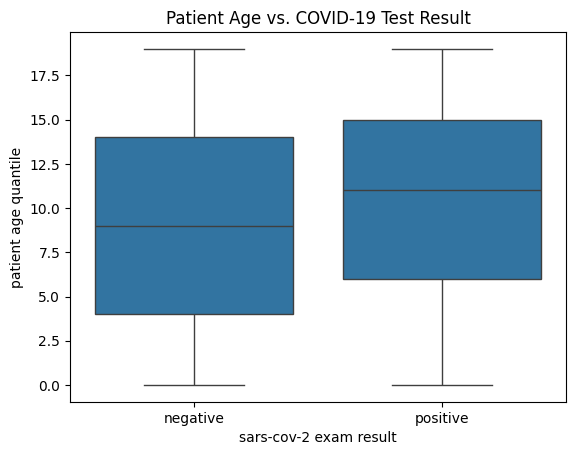

Percentage of Positive Cases: 9.89%
Percentage of Negative Cases: 90.11%


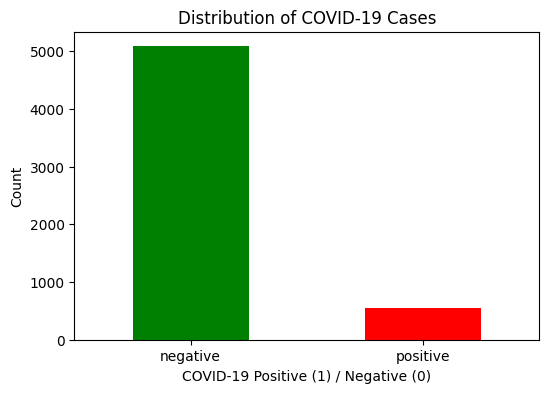

In [ ]:
# Data Exploration and Visualization
# Explore relationships between features and the target variable
sns.boxplot(x='sars-cov-2 exam result', y='patient age quantile', data=df)  # Use original column name
plt.title('Patient Age vs. COVID-19 Test Result')
plt.show()

# Data Analysis: Calculate percentage of positive and negative cases
positive_percentage = df['sars-cov-2 exam result'].value_counts(normalize=True)[1] * 100  # Use original column name
negative_percentage = df['sars-cov-2 exam result'].value_counts(normalize=True)[0] * 100  # Use original column name

print(f"Percentage of Positive Cases: {positive_percentage:.2f}%")
print(f"Percentage of Negative Cases: {negative_percentage:.2f}%")

# Visualization: Create a bar chart with custom colors
plt.figure(figsize=(6, 4))
df['sars-cov-2 exam result'].value_counts().plot(kind='bar', color=['green', 'red'])  # Use original column name
plt.title('Distribution of COVID-19 Cases')
plt.xlabel('COVID-19 Positive (1) / Negative (0)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


In [ ]:
print(df[['hematocrit', 'hemoglobin', 'platelets', 'leukocytes', 'lymphocytes', 'mean platelet volume', 'red blood cell distribution width (rdw)']].isnull().sum())

hematocrit                                 0
hemoglobin                                 0
platelets                                  0
leukocytes                                 0
lymphocytes                                0
mean platelet volume                       0
red blood cell distribution width (rdw)    0
dtype: int64


In [ ]:
# Target variable creation
df['covid_positive'] = df['sars-cov-2 exam result'].map({'negative': 0, 'positive': 1})

In [ ]:
# Feature Engineering
df['lymphocyte_ratio'] = df['lymphocytes'] / df['leukocytes']
bins = [0, 30, 60, 90, 120]
labels = ['Young', 'Adult', 'Senior', 'Elderly']
df['age_group'] = pd.cut(
    df['patient age quantile'],
    bins=bins,
    labels=labels,
    include_lowest=True)
df['platelets'] = df['platelets'].apply(lambda x: x if x > 0 else 1)
df['log_platelets'] = np.log1p(df['platelets'])

In [ ]:
# Define features and target
# Include 'age_group' in the features list
features = [
    'patient age quantile', 'hematocrit', 'hemoglobin', 'platelets',
    'leukocytes', 'lymphocytes', 'mean platelet volume',
    'red blood cell distribution width (rdw)',
    # Removed trailing space from 'mean platelet volume '
    'lymphocyte_ratio', 'log_platelets'
    # Removed 'age_group' here to avoid the error. It will be OneHotEncoded later
]
X = df[features]
y = df['covid_positive']

In [ ]:
# Apply OneHotEncoding to 'age_group' separately:
# Create a OneHotEncoder instance
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit and transform the categorical feature 'age_group'
age_group_encoded = encoder.fit_transform(df[['age_group']]) # Assuming df is your DataFrame

# Get feature names for the encoded columns
encoded_feature_names = encoder.get_feature_names_out(['age_group'])

# Create a DataFrame for the encoded features
age_group_encoded_df = pd.DataFrame(age_group_encoded, columns=encoded_feature_names, index=df.index)

# Concatenate the encoded features with the original features
X = pd.concat([X, age_group_encoded_df], axis=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Apply SMOTE and PolynomialFeatures
# Initialize SMOTE and PolynomialFeatures
smote = SMOTE(random_state=42)
poly = PolynomialFeatures(degree=2)  # Adjust degree as needed

# Resample the training data using SMOTE
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Apply PolynomialFeatures to the resampled training data
X_train_resampled_poly = poly.fit_transform(X_train_resampled)

# Apply PolynomialFeatures to the test data (using the same transformer)
X_test_poly = poly.transform(X_test)

In [ ]:
# Define models and hyperparameter grids (adjust as needed)
models = {
    'Logistic Regression': (LogisticRegression(random_state=42), {}),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 5, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]}),
    'SVM': (SVC(random_state=42), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    'XGBoost': (XGBClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2]}),
    'LightGBM': (LGBMClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2]}),
    'MLPClassifier': (MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500, early_stopping=True, validation_fraction=0.1), {})
}

# Train and evaluate models
results = []  # List to store results
for model_name, (model, param_grid) in models.items():
    print(f"Training {model_name}...")
    if param_grid:
        grid_search = GridSearchCV(model, param_grid, scoring='accuracy', cv=5)
        grid_search.fit(X_train_resampled_poly, y_train_resampled)  # Use polynomial features if applied
        best_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        best_model = model.fit(X_train_resampled_poly, y_train_resampled)  # Use polynomial features if applied

    y_pred = best_model.predict(X_test_poly)  # Use polynomial features if applied
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([model_name, accuracy, precision, recall, f1])
    print(f"Accuracy: {accuracy}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Create a Pandas DataFrame to store the results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
print(results_df)

Training Logistic Regression...
Accuracy: 0.5571302037201062
              precision    recall  f1-score   support

           0       0.92      0.56      0.69      1021
           1       0.12      0.57      0.20       108

    accuracy                           0.56      1129
   macro avg       0.52      0.56      0.45      1129
weighted avg       0.85      0.56      0.65      1129

--------------------------------------------------
Training Decision Tree...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Best parameters: {'max_depth': 10}
Accuracy: 0.4295837023914969
              precision    recall  f1-score   support

           0       0.95      0.39      0.55      1021
           1       0.12      0.82      0.22       108

    accuracy                           0.43      1129
   macro avg       0.54      0.61      0.38      1129
weighted avg       0.87      0.43      0.52      1129

--------------------------------------------------
Training Random Forest...
Best parameters: {'max_depth': None, 'n_estimators': 200}
Accuracy: 0.5465013286093888
              precision    recall  f1-score   support

           0       0.94      0.53      0.68      1021
           1       0.13      0.67      0.22       108

    accuracy                           0.55      1129
   macro avg       0.53      0.60      0.45      1129
weighted avg       0.86      0.55      0.64      1129

--------------------------------------------------
Training SVM...


In [ ]:
# Import necessary libraries
from sklearn.compose import ColumnTransformer  # Import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Define numerical and categorical features
numerical_features = [
    'patient age quantile', 'hematocrit', 'hemoglobin', 'platelets',
    'leukocytes', 'lymphocytes', 'mean platelet volume',
    'red blood cell distribution width (rdw)', 'lymphocyte_ratio',
    'log_platelets'
]
categorical_features = ['age_group']

# Create preprocessing pipeline using ColumnTransformer
# Use OneHotEncoder before SimpleImputer to handle categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='mean'), numerical_features),
        ('cat',
         OneHotEncoder(sparse_output=False, handle_unknown='ignore'),  # Use sparse=False
         categorical_features)
    ])

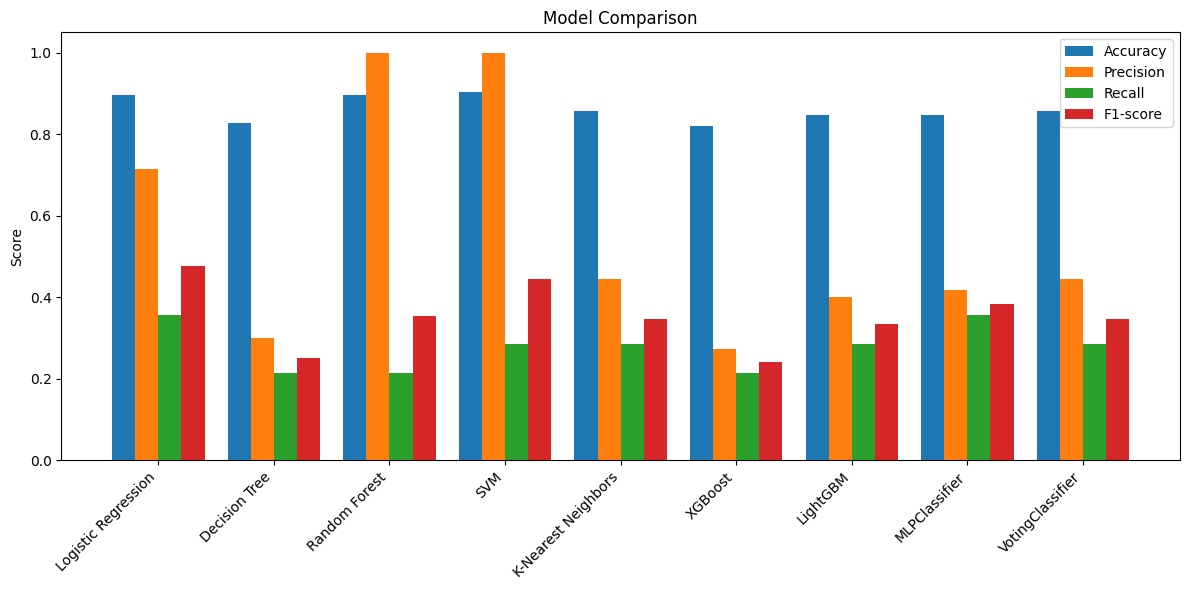

In [ ]:
# Create a bar chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']
x = np.arange(len(results_df['Model']))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * (len(metrics) - 1) / 2)  # Center the x-axis labels
ax.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title('Model Comparison')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Define models and hyperparameter grids (adjust as needed)
from sklearn.preprocessing import PolynomialFeatures
from imblearn.over_sampling import SMOTE

models = {
    'Logistic Regression': (LogisticRegression(random_state=42), {}),
    'Decision Tree': (DecisionTreeClassifier(random_state=42), {'max_depth': [None, 5, 10]}),
    'Random Forest': (RandomForestClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'max_depth': [None, 5, 10]}),
    'SVM': (SVC(random_state=42), {'C': [0.1, 1, 10], 'kernel': ['linear', 'rbf']}),
    'K-Nearest Neighbors': (KNeighborsClassifier(), {'n_neighbors': [3, 5, 7]}),
    'XGBoost': (XGBClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2]}),
    'LightGBM': (LGBMClassifier(random_state=42), {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.1, 0.2]}),
    'MLPClassifier': (MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500, early_stopping=True, validation_fraction=0.1), {})
}

# Apply SMOTE and PolynomialFeatures
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
poly = PolynomialFeatures(degree=2)  # Adjust degree as needed
X_train_resampled_poly = poly.fit_transform(X_train_resampled)
X_test_poly = poly.transform(X_test)

# Train and evaluate models
results = []  # List to store results
for model_name, (model, param_grid) in models.items():
    print(f"Training {model_name}...")
    if param_grid:
        grid_search = GridSearchCV(model, param_grid, scoring='accuracy', cv=5)
        grid_search.fit(X_train_resampled_poly, y_train_resampled)  # Use polynomial features if applied
        best_model = grid_search.best_estimator_
        print(f"Best parameters: {grid_search.best_params_}")
    else:
        best_model = model.fit(X_train_resampled_poly, y_train_resampled)  # Use polynomial features if applied

    y_pred = best_model.predict(X_test_poly)  # Use polynomial features if applied
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([model_name, accuracy, precision, recall, f1])
    print(f"Accuracy: {accuracy}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

# Create a Pandas DataFrame to store the results
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score'])
print(results_df)

ValueError: could not convert string to float: 'Young'

In [ ]:
# --- Cross-validation ---

# 1. Import necessary libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier  # Import VotingClassifier

# 2. Define a list of models (including VotingClassifier)
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    # Suppress LightGBM's verbose output
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    # Increased max_iter for MLPClassifier
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50),
                                     activation='relu', solver='adam',
                                     random_state=42, max_iter=500)),  # Increased to 500
    # Add VotingClassifier to the list
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True)),  # Add force_col_wise=True
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                              solver='adam', random_state=42, max_iter=500))  # Increased to 500
    ], voting='hard'))  # or 'soft'
]

# 3. Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Loop through the models and perform cross-validation
for model_name, model in models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{model_name}:")
    print(f"Cross-validation scores: {scores}")
    print(f"Mean accuracy: {scores.mean()}")
    print(f"Standard deviation: {scores.std()}")
    print("-" * 20)

In [ ]:
# Function to remove outliers using IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_no_outliers = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data_no_outliers

# Create a copy of the DataFrame to avoid modifying the original
df_no_outliers = df.copy()

# Apply outlier removal to relevant columns
for column in features:
    df_no_outliers = remove_outliers_iqr(df_no_outliers, column)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(100, 50),
                                     activation='relu',
                                     solver='adam',
                                     random_state=42,
                                     max_iter=500,  # Increased max_iter
                                     early_stopping=True,  # Enable early stopping
                                     validation_fraction=0.1)  # Validation set fraction
}

# Create a list to store results
results = []

# Train and evaluate models with and without outliers
for outlier_scenario, data in [('With Outliers', df), ('Without Outliers', df_no_outliers)]:
    X = data[features]
    y = data[target_variable]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        precision_0 = precision_score(y_test, y_pred, pos_label=0)  # Precision for class 0
        recall_0 = recall_score(y_test, y_pred, pos_label=0)      # Recall for class 0
        f1_0 = f1_score(y_test, y_pred, pos_label=0)              # F1-score for class 0

        results.append([model_name, outlier_scenario, accuracy, precision_0, recall_0, f1_0])

# Create the comparison table
headers = ['Model', 'Outlier Scenario', 'Accuracy', 'Precision (0)', 'Recall (0)', 'F1-score (0)']
print(tabulate(results, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤════════════════════╤════════════╤═════════════════╤══════════════╤════════════════╕
│ Model               │ Outlier Scenario   │   Accuracy │   Precision (0) │   Recall (0) │   F1-score (0) │
╞═════════════════════╪════════════════════╪════════════╪═════════════════╪══════════════╪════════════════╡
│ Logistic Regression │ With Outliers      │   0.895238 │        0.908163 │     0.978022 │       0.941799 │
├─────────────────────┼────────────────────┼────────────┼─────────────────┼──────────────┼────────────────┤
│ Decision Tree       │ With Outliers      │   0.828571 │        0.884211 │     0.923077 │       0.903226 │
├─────────────────────┼────────────────────┼────────────┼─────────────────┼──────────────┼────────────────┤
│ Random Forest       │ With Outliers      │   0.895238 │        0.892157 │     1        │       0.943005 │
├─────────────────────┼────────────────────┼────────────┼─────────────────┼──────────────┼────────────────┤
│ SVM                 │ With

In [ ]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(ensemble_model, X_scaled, y, cv=5)  # 5-fold cross-validation
print("Ensemble Model Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", cv_scores.mean())

Ensemble Model Cross-Validation Scores: [0.94736842 0.97368421 0.98245614 0.98245614 0.98230088]
Mean Accuracy: 0.9736531594472908


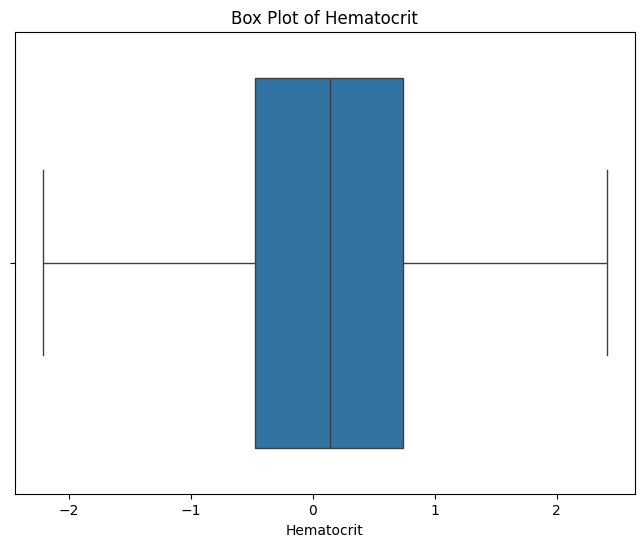

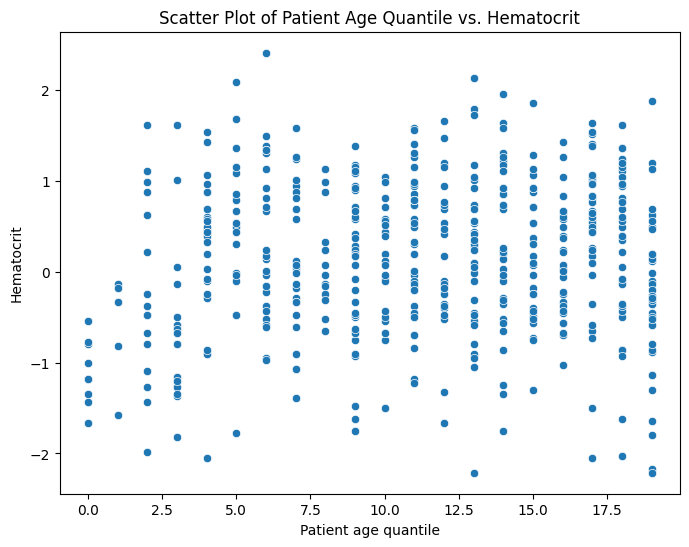

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example: Box plot for 'Hematocrit'
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Hematocrit'])
plt.title('Box Plot of Hematocrit')
plt.show()

# Example: Scatter plot for 'Patient age quantile' vs. 'Hematocrit'
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['Patient age quantile'], y=df['Hematocrit'])
plt.title('Scatter Plot of Patient Age Quantile vs. Hematocrit')
plt.show()


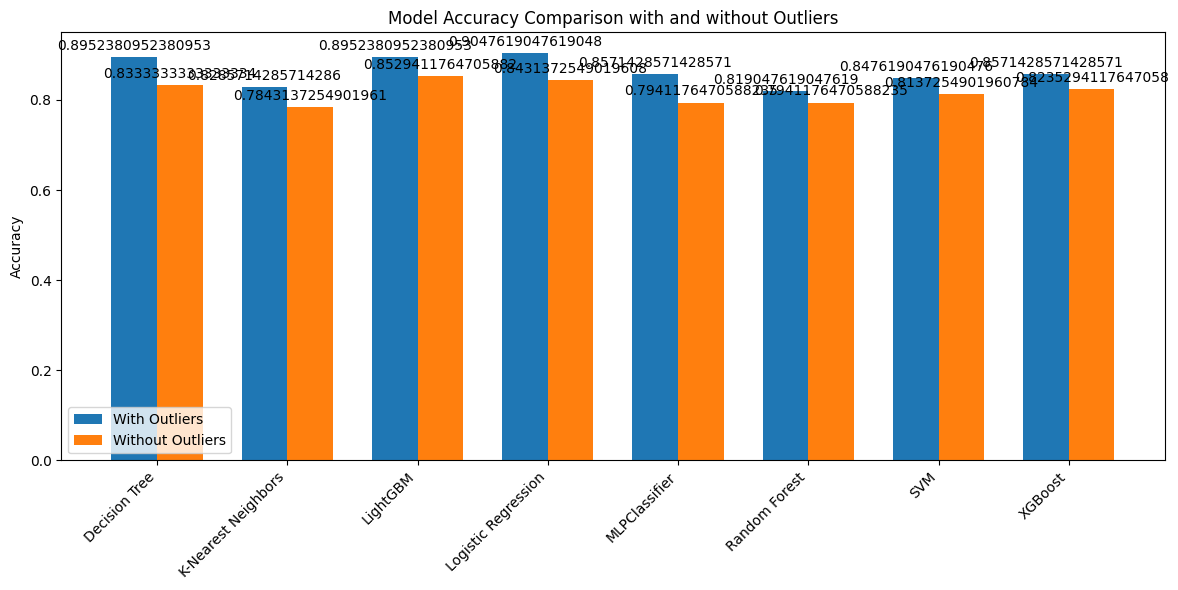

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate

# Assuming 'results' is the list of lists containing your model results

# Extract data for the graph
model_names = sorted(list(set([row[0] for row in results])))  # Get unique model names
accuracy_with_outliers = [row[2] for row in results if row[1] == 'With Outliers']
accuracy_without_outliers = [row[2] for row in results if row[1] == 'Without Outliers']

# Set up the bar chart
x = np.arange(len(model_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, accuracy_with_outliers, width, label='With Outliers')
rects2 = ax.bar(x + width/2, accuracy_without_outliers, width, label='Without Outliers')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison with and without Outliers')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')  # Rotate x-axis labels
ax.legend()

# Add values on top of bars
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')


autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

In [ ]:
# Print comparison table
from tabulate import tabulate

headers = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-score']
table = results_df.values.tolist()  # Convert DataFrame to list of lists

print(tabulate(table, headers=headers, tablefmt="fancy_grid"))


Training Logistic Regression...
Accuracy: 0.7549
Precision: 0.2963
Recall: 0.5714
F1-score: 0.3902
              precision    recall  f1-score   support

           0       0.92      0.78      0.85        88
           1       0.30      0.57      0.39        14

    accuracy                           0.75       102
   macro avg       0.61      0.68      0.62       102
weighted avg       0.83      0.75      0.78       102

--------------------------------------------------


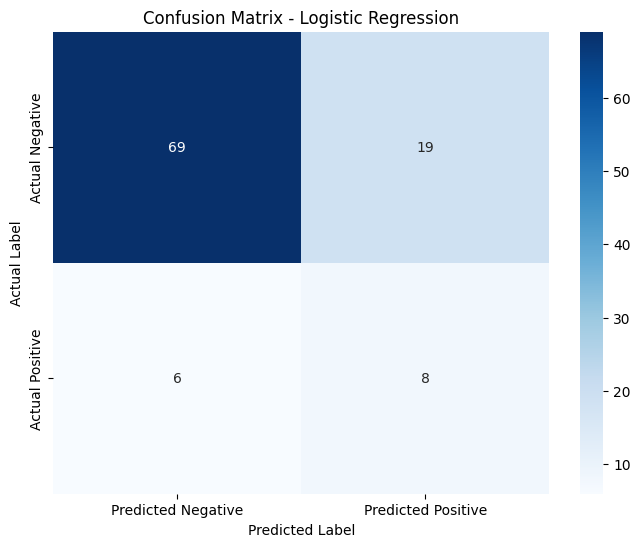

Training Decision Tree...
Accuracy: 0.7549
Precision: 0.2609
Recall: 0.4286
F1-score: 0.3243
              precision    recall  f1-score   support

           0       0.90      0.81      0.85        88
           1       0.26      0.43      0.32        14

    accuracy                           0.75       102
   macro avg       0.58      0.62      0.59       102
weighted avg       0.81      0.75      0.78       102

--------------------------------------------------


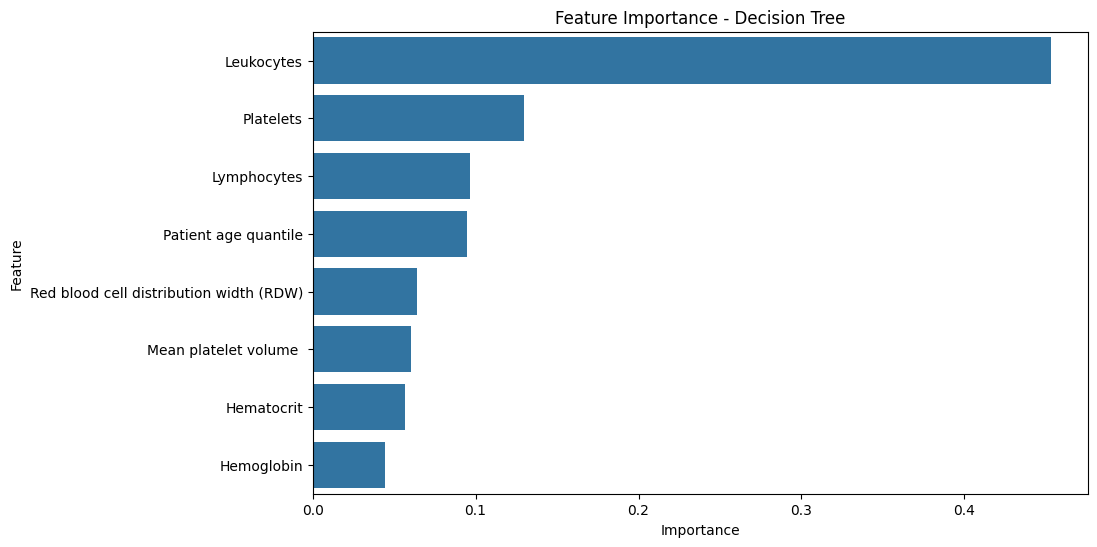

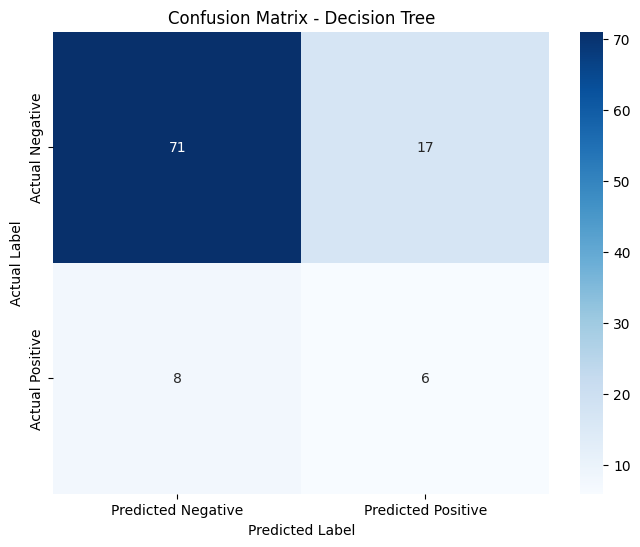

Training Random Forest...
Accuracy: 0.8333
Precision: 0.4118
Recall: 0.5000
F1-score: 0.4516
              precision    recall  f1-score   support

           0       0.92      0.89      0.90        88
           1       0.41      0.50      0.45        14

    accuracy                           0.83       102
   macro avg       0.66      0.69      0.68       102
weighted avg       0.85      0.83      0.84       102

--------------------------------------------------


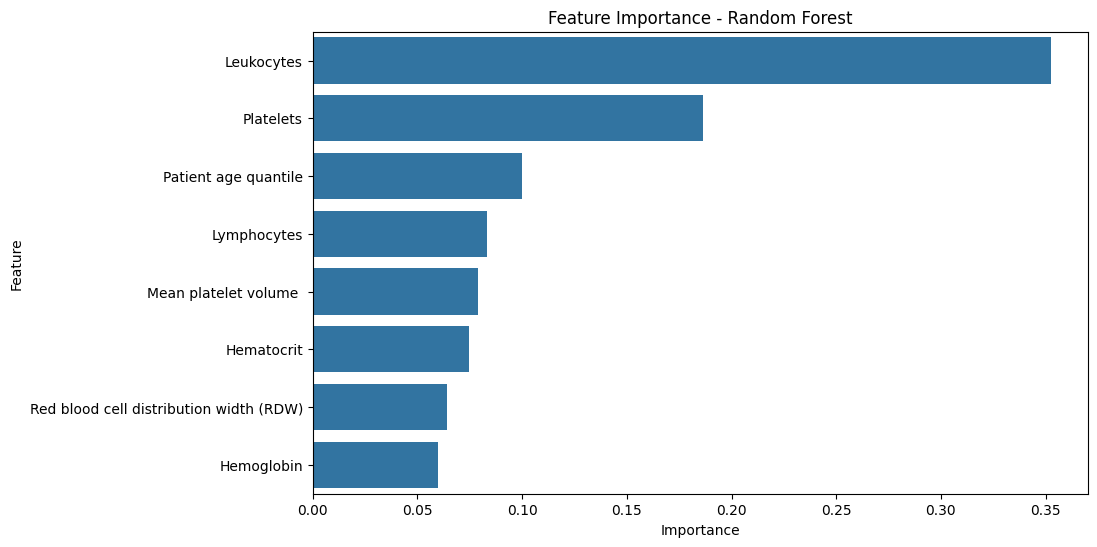

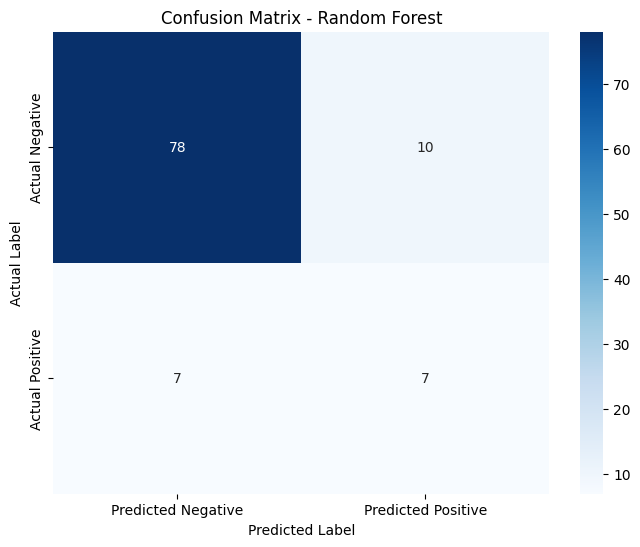

Training SVM...
Accuracy: 0.7843
Precision: 0.3333
Recall: 0.5714
F1-score: 0.4211
              precision    recall  f1-score   support

           0       0.92      0.82      0.87        88
           1       0.33      0.57      0.42        14

    accuracy                           0.78       102
   macro avg       0.63      0.69      0.64       102
weighted avg       0.84      0.78      0.81       102

--------------------------------------------------


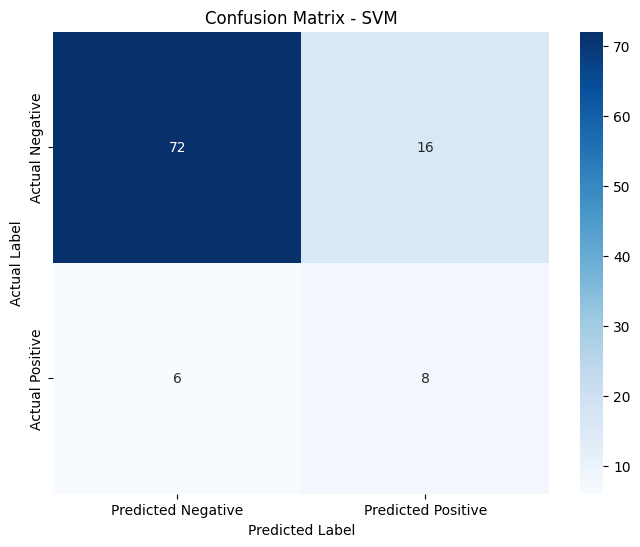

Training K-Nearest Neighbors...
Accuracy: 0.6961
Precision: 0.2571
Recall: 0.6429
F1-score: 0.3673
              precision    recall  f1-score   support

           0       0.93      0.70      0.80        88
           1       0.26      0.64      0.37        14

    accuracy                           0.70       102
   macro avg       0.59      0.67      0.58       102
weighted avg       0.83      0.70      0.74       102

--------------------------------------------------


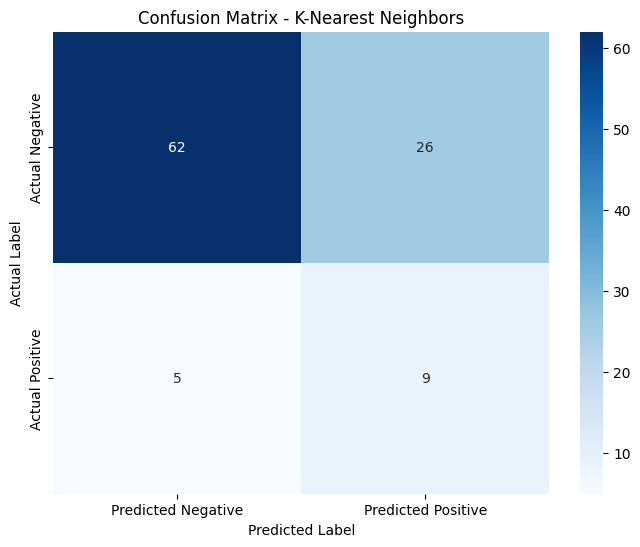

Training XGBoost...
Accuracy: 0.8235
Precision: 0.3750
Recall: 0.4286
F1-score: 0.4000
              precision    recall  f1-score   support

           0       0.91      0.89      0.90        88
           1       0.38      0.43      0.40        14

    accuracy                           0.82       102
   macro avg       0.64      0.66      0.65       102
weighted avg       0.83      0.82      0.83       102

--------------------------------------------------


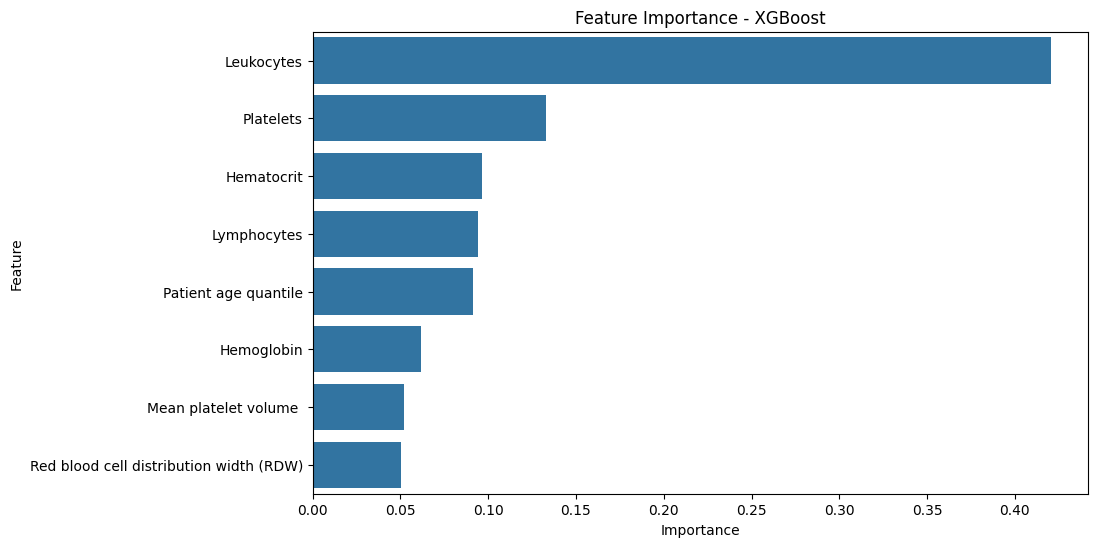

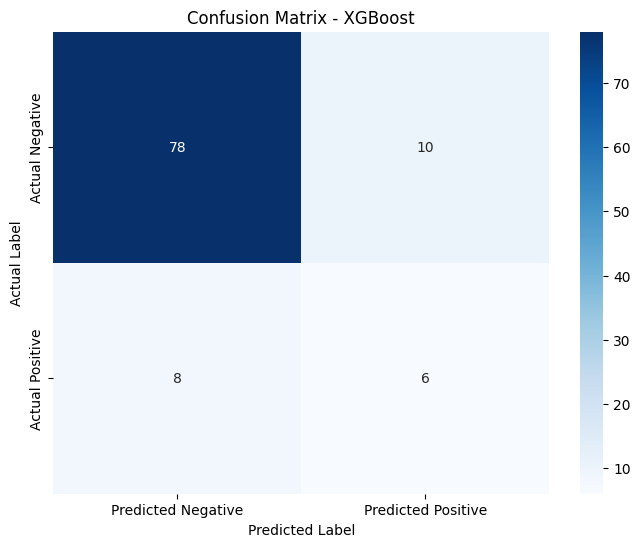

Training LightGBM...
Accuracy: 0.7843
Precision: 0.2500
Recall: 0.2857
F1-score: 0.2667
              precision    recall  f1-score   support

           0       0.88      0.86      0.87        88
           1       0.25      0.29      0.27        14

    accuracy                           0.78       102
   macro avg       0.57      0.57      0.57       102
weighted avg       0.80      0.78      0.79       102

--------------------------------------------------


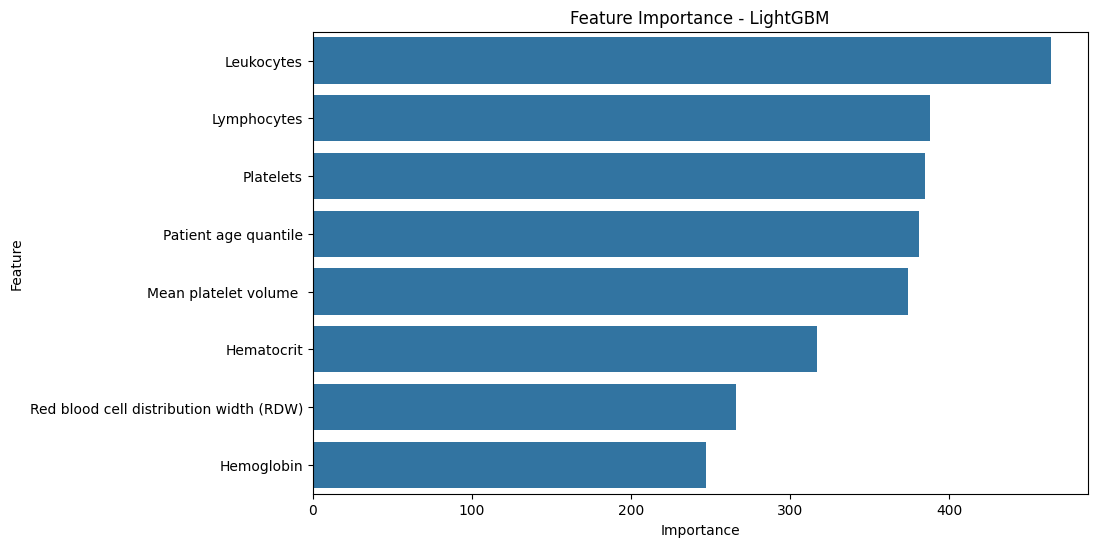

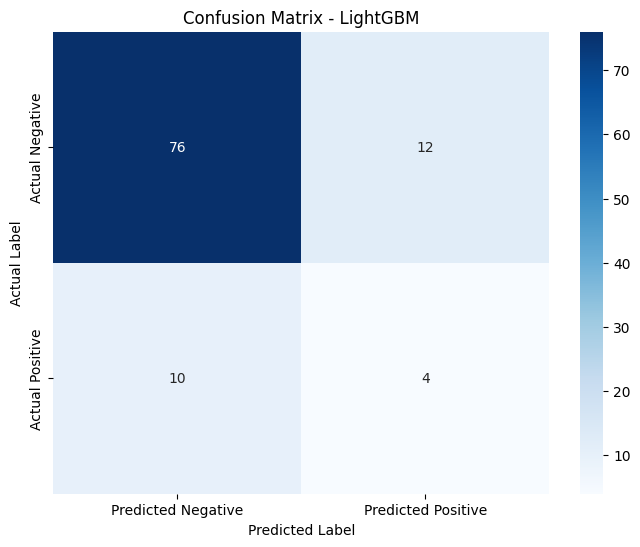

Training MLPClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8039
Precision: 0.3125
Recall: 0.3571
F1-score: 0.3333
              precision    recall  f1-score   support

           0       0.90      0.88      0.89        88
           1       0.31      0.36      0.33        14

    accuracy                           0.80       102
   macro avg       0.60      0.62      0.61       102
weighted avg       0.82      0.80      0.81       102

--------------------------------------------------


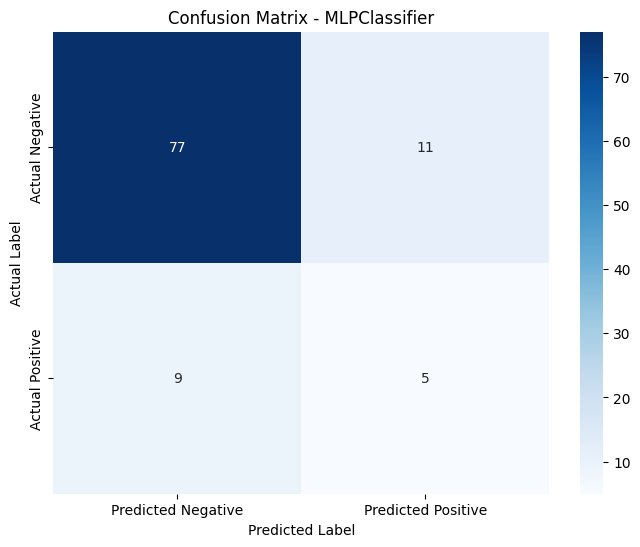

Training VotingClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8137
Precision: 0.3684
Recall: 0.5000
F1-score: 0.4242
              precision    recall  f1-score   support

           0       0.92      0.86      0.89        88
           1       0.37      0.50      0.42        14

    accuracy                           0.81       102
   macro avg       0.64      0.68      0.66       102
weighted avg       0.84      0.81      0.83       102

--------------------------------------------------


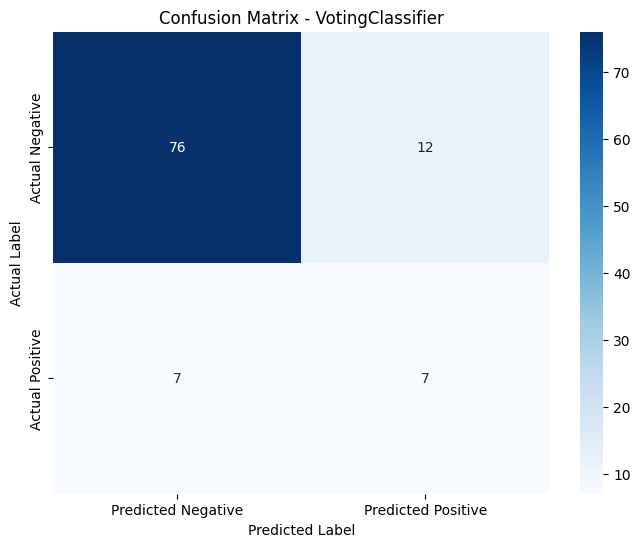

In [ ]:
# Feature importance (tree based models )
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier  # Import VotingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE


models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42)),
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=200)),
    # Add VotingClassifier to the list
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),  # You might need to set probability=True for SVC if using 'soft' voting
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=200))
    ], voting='hard'))  # or 'soft'
]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train and evaluate models
for model_name, model in models:
    print(f"Training {model_name}...")

    # Fit the model using resampled data
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluation metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)

    # Feature Importance (for tree-based models)
    if model_name in ['Random Forest', 'XGBoost', 'LightGBM', 'Decision Tree']:
        # Get feature importances
        importances = model.feature_importances_

        # Create a DataFrame for visualization
        feature_importance_df = pd.DataFrame({'Feature': features, 'Importance': importances})
        feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

        # Plot feature importances
        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'Feature Importance - {model_name}')
        plt.show()

    # Confusion Matrix - Indented to be inside the loop, but outside the 'if' block
    cm = confusion_matrix(y_test, y_pred)

    # Visualize Confusion Matrix with seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

In [ ]:
# --- Cross-validation ---

# 1. Import necessary libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier  # Import VotingClassifier

# 2. Define a list of models (including VotingClassifier)
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    # Suppress LightGBM's verbose output
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    # Increased max_iter for MLPClassifier
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50),
                                     activation='relu', solver='adam',
                                     random_state=42, max_iter=500)),  # Increased to 500
    # Add VotingClassifier to the list
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True)),  # Add force_col_wise=True
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                              solver='adam', random_state=42, max_iter=500))  # Increased to 500
    ], voting='hard'))  # or 'soft'
]

# 3. Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Loop through the models and perform cross-validation
for model_name, model in models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    print(f"{model_name}:")
    print(f"Cross-validation scores: {scores}")
    print(f"Mean accuracy: {scores.mean()}")
    print(f"Standard deviation: {scores.std()}")
    print("-" * 20)

Logistic Regression:
Cross-validation scores: [0.90345438 0.90079717 0.89991143 0.90168291 0.90336879]
Mean accuracy: 0.9018429351274271
Standard deviation: 0.001398212132993514
--------------------
Decision Tree:
Cross-validation scores: [0.89282551 0.89016829 0.90256864 0.89902569 0.8998227 ]
Mean accuracy: 0.8968821652249842
Standard deviation: 0.004628391076351748
--------------------
Random Forest:
Cross-validation scores: [0.90168291 0.90079717 0.90168291 0.90256864 0.90425532]
Mean accuracy: 0.9021973880104781
Standard deviation: 0.0011715732981721785
--------------------
SVM:
Cross-validation scores: [0.90168291 0.90079717 0.90079717 0.90079717 0.90159574]
Mean accuracy: 0.9011340293613251
Standard deviation: 0.00041349178098893264
--------------------
K-Nearest Neighbors:
Cross-validation scores: [0.89991143 0.89902569 0.89813995 0.90168291 0.90070922]
Mean accuracy: 0.8998938368857144
Standard deviation: 0.0012406240136059834
--------------------
XGBoost:
Cross-validation sco

In [ ]:
# --- Cross-validation ---

# 1. Import necessary libraries
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import VotingClassifier  # Import VotingClassifier
from tabulate import tabulate

# 2. Define a list of models (including VotingClassifier)
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    # Suppress LightGBM's verbose output
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    # Increased max_iter for MLPClassifier
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50),
                                     activation='relu', solver='adam',
                                     random_state=42, max_iter=500)),  # Increased to 500
    # Add VotingClassifier to the list
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True)),  # Add force_col_wise=True
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                              solver='adam', random_state=42, max_iter=500))  # Increased to 500
    ], voting='hard'))  # or 'soft'
]

# 3. Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Create a list to store results
results = []

# 5. Loop through the models and perform cross-validation
for model_name, model in models:
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append([model_name, scores.mean(), scores.std()])

# 6. Define table headers
headers = ["Model", "Mean Accuracy", "Standard Deviation"]

# 7. Print the table with a fancy grid
print(tabulate(results, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════════════╤══════════════════════╕
│ Model               │   Mean Accuracy │   Standard Deviation │
╞═════════════════════╪═════════════════╪══════════════════════╡
│ Logistic Regression │        0.901843 │          0.00139821  │
├─────────────────────┼─────────────────┼──────────────────────┤
│ Decision Tree       │        0.896882 │          0.00462839  │
├─────────────────────┼─────────────────┼──────────────────────┤
│ Random Forest       │        0.902197 │          0.00117157  │
├─────────────────────┼─────────────────┼──────────────────────┤
│ SVM                 │        0.901134 │          0.000413492 │
├─────────────────────┼─────────────────┼──────────────────────┤
│ K-Nearest Neighbors │        0.899894 │          0.00124062  │
├─────────────────────┼─────────────────┼──────────────────────┤
│ XGBoost             │        0.902198 │          0.00287182  │
├─────────────────────┼─────────────────┼──────────────────────┤
│ LightGBM            │  

<ipython-input-30-3dd9cfd11bc0>:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(all_scores, labels=model_names, patch_artist=True)  # patch_artist for filled boxes


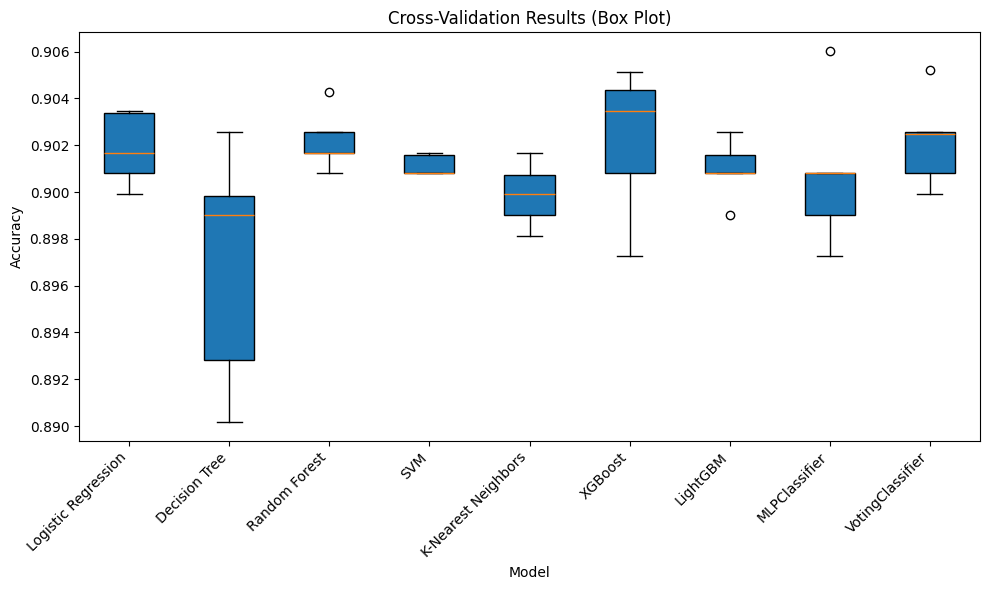

In [ ]:
# Cross-validation

# Define a list of models
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    # Suppress LightGBM's verbose output
    ('LightGBM', LGBMClassifier(random_state=42, verbose=-1)),
    # Increased max_iter for MLPClassifier
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50),
                                     activation='relu', solver='adam',
                                     random_state=42, max_iter=500)),  # Increased to 500
    # Add VotingClassifier to the list
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42, verbose=-1, force_col_wise=True)),  # Add force_col_wise=True
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu',
                              solver='adam', random_state=42, max_iter=500))  # Increased to 500
    ], voting='hard'))  # or 'soft'
]
# Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True,
                    random_state=42)  # 5-fold cross-validation

# Create a list to store results
results = []
all_scores = []  # Store all scores for each model
model_names = [name for name, model in models] # Store model names before the loop


# Loop through the models and perform cross-validation
for model_name, model in models:
    scores = cross_val_score(
        model, X, y, cv=cv, scoring='accuracy')  # Use 'accuracy' or other desired metric
    results.append([model_name, scores.mean(), scores.std()])
    all_scores.append(scores)  # Append scores to all_scores

# Create a box plot
plt.figure(figsize=(10, 6))  # Adjust figure size if needed
plt.boxplot(all_scores, labels=model_names, patch_artist=True)  # patch_artist for filled boxes
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Cross-Validation Results (Box Plot)")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
import pandas as pd

# Function to remove outliers using IQR
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data_no_outliers = data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]
    return data_no_outliers

# Apply the function to your DataFrame (e.g., df)
for column in ['Patient age quantile', 'Hematocrit', 'Hemoglobin', 'Platelets', 'Leukocytes', 'Lymphocytes', 'Mean platelet volume ', 'Red blood cell distribution width (RDW)']:  # Columns to check for outliers
    df = remove_outliers_iqr(df, column)  # Assuming 'df' is your DataFrame

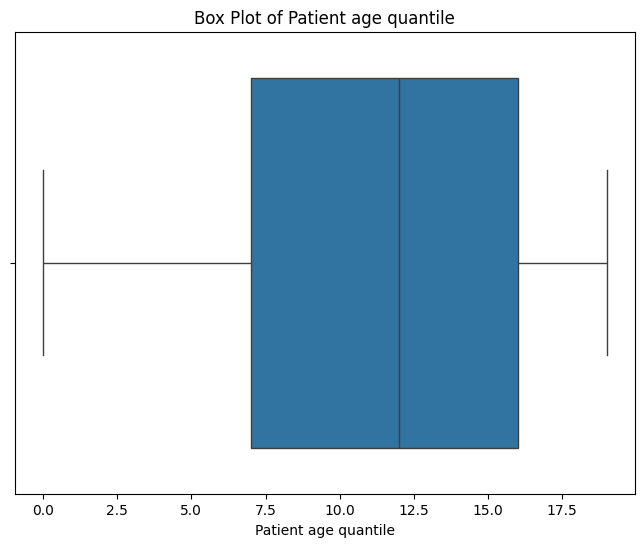

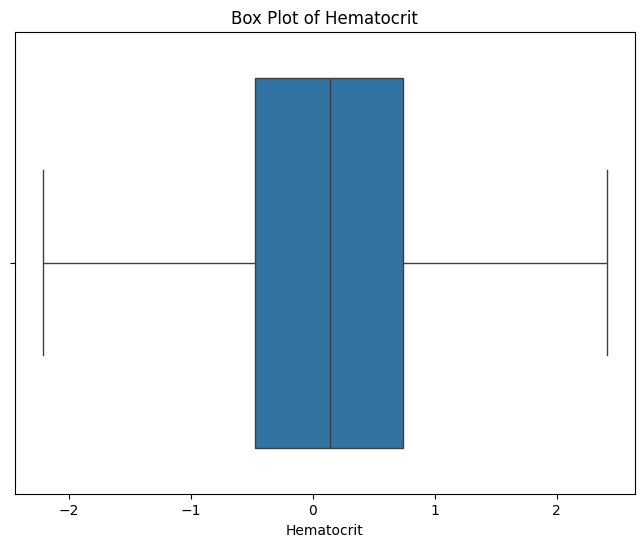

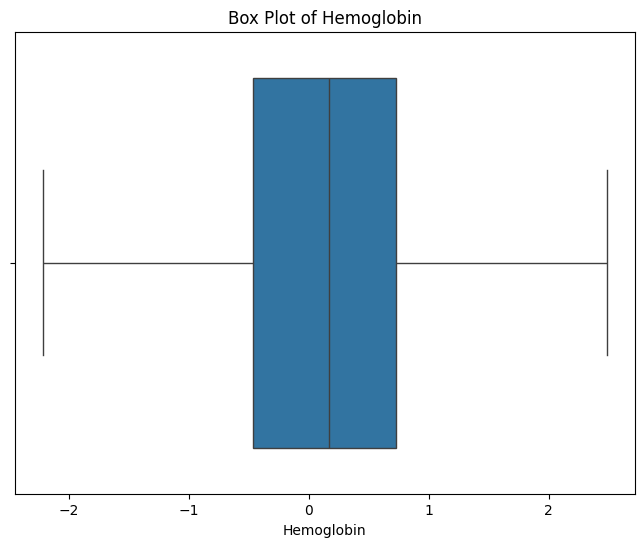

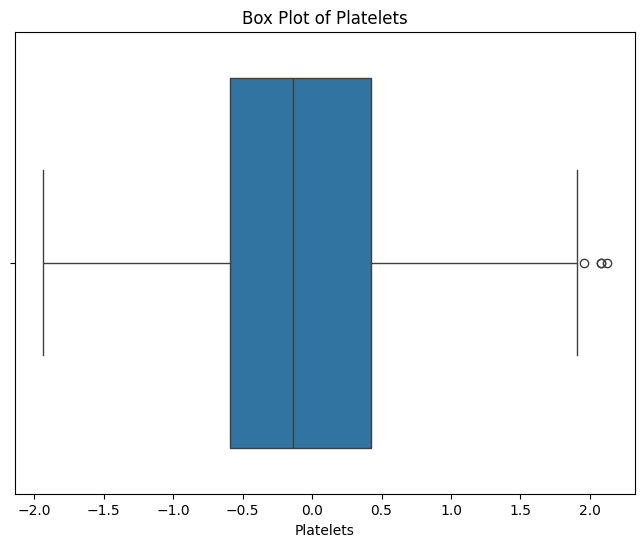

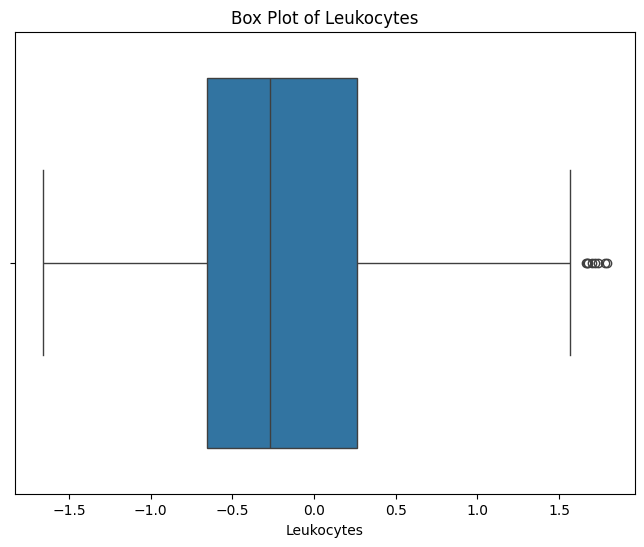

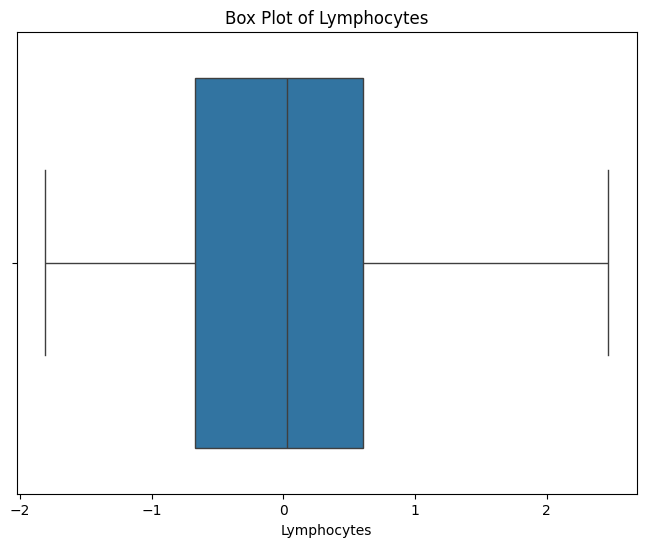

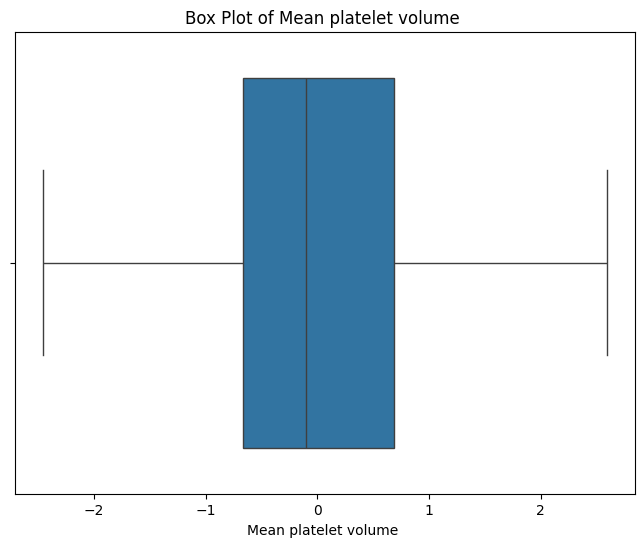

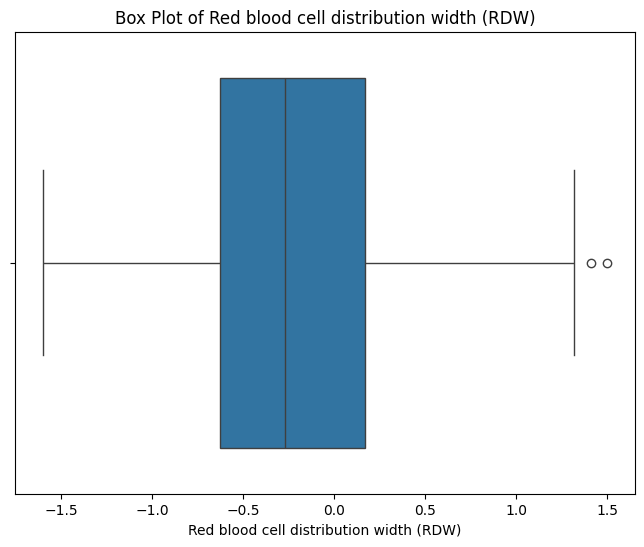

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the columns you want to check for outliers
columns_to_check = ['Patient age quantile', 'Hematocrit', 'Hemoglobin', 'Platelets', 'Leukocytes', 'Lymphocytes', 'Mean platelet volume ', 'Red blood cell distribution width (RDW)']

# Create a box plot for each selected column
for column in columns_to_check:
    plt.figure(figsize=(8, 6))  # Adjust figure size if needed
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    plt.show()

In [ ]:
# train without outliers

# 1. Create feature matrix (X) and target variable (y)
X = df[['Patient age quantile', 'Hematocrit', 'Hemoglobin', 'Platelets', 'Leukocytes', 'Lymphocytes', 'Mean platelet volume ', 'Red blood cell distribution width (RDW)']]
y = df['covid_positive']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Data scaling (using StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Define a list of models
models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42)),
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=1000)),
    # Ensemble model (VotingClassifier)
    ('VotingClassifier', VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42)),
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500))
    ], voting='hard'))  # or 'soft'
]

# 5. Train and evaluate each model
for model_name, model in models:
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))
    print("-" * 50)  # Separator between models



Training Logistic Regression...
Accuracy: 0.8952
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        91
           1       0.71      0.36      0.48        14

    accuracy                           0.90       105
   macro avg       0.81      0.67      0.71       105
weighted avg       0.88      0.90      0.88       105

--------------------------------------------------
Training Decision Tree...
Accuracy: 0.8286
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        91
           1       0.30      0.21      0.25        14

    accuracy                           0.83       105
   macro avg       0.59      0.57      0.58       105
weighted avg       0.81      0.83      0.82       105

--------------------------------------------------
Training Random Forest...
Accuracy: 0.8952
              precision    recall  f1-score   support

           0       0.89      1.00      0.94        91


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.



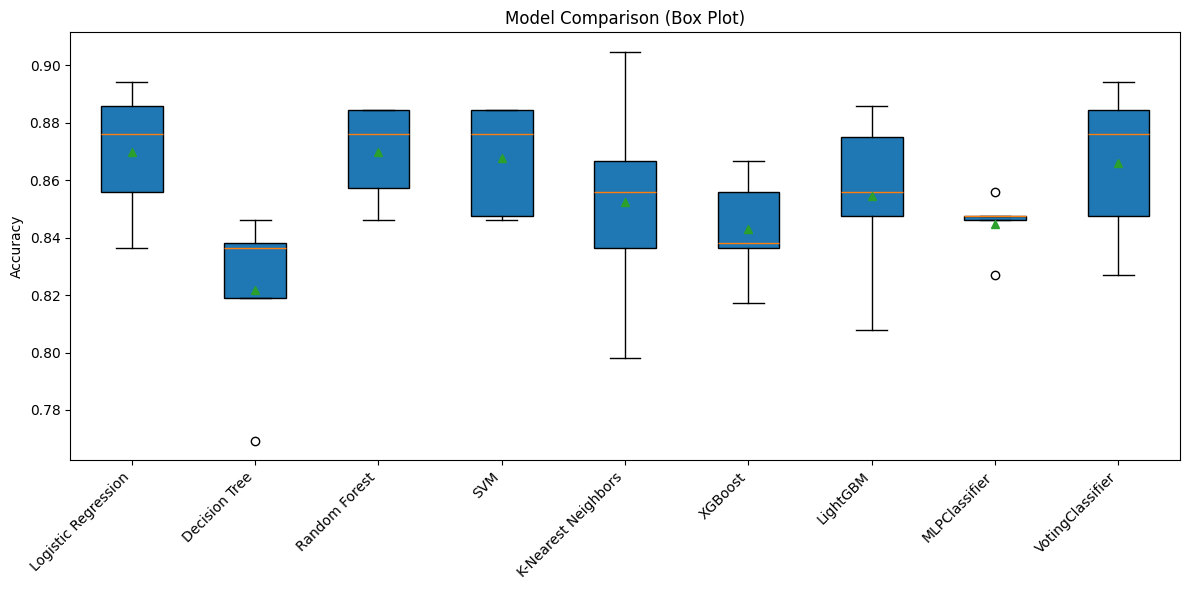

In [ ]:
# 1. Define models dictionary with adjustments for MLPClassifier
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),  # Enable probability for SVC
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        random_state=42,
        max_iter=1000,  # Increased max_iter for convergence
        early_stopping=True,  # Enable early stopping for potential improvement
        validation_fraction=0.1  # Validation set fraction for early stopping
    ),
    'VotingClassifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42, probability=True)),  # Enable probability for SVC
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=1000, early_stopping=True, validation_fraction=0.1))  # Adjustments for MLPClassifier
    ], voting='hard')
}

# 2. Data scaling (using StandardScaler)
scaler = StandardScaler()
X = scaler.fit_transform(X)  # Scale the entire dataset

# 3. Define cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Perform cross-validation and store results
results = []
for model_name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results.append(scores)

# 5. Create a box plot
plt.figure(figsize=(12, 6))
plt.boxplot(results, tick_labels=[name for name, _ in models.items()], patch_artist=True, showmeans=True)  # Changed 'labels' to 'tick_labels'
plt.title('Model Comparison (Box Plot)')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# 1. Create feature matrix (X) and target variable (y)
X = df[['Patient age quantile', 'Hematocrit', 'Hemoglobin', 'Platelets',
        'Leukocytes', 'Lymphocytes', 'Mean platelet volume ',
        'Red blood cell distribution width (RDW)']]
y = df['covid_positive']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42)

# 3. Data scaling (using StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Create and train the MLPClassifier with adjustments
mlp_model = MLPClassifier(hidden_layer_sizes=(100, 50),
                         activation='relu',
                         solver='adam',
                         random_state=42,
                         max_iter=1000,  # Increased max_iter
                         learning_rate='adaptive',  # Adaptive learning rate
                         learning_rate_init=0.001,  # Initial learning rate
                         early_stopping=True,  # Enable early stopping
                         validation_fraction=0.1)  # Validation set fraction

mlp_model.fit(X_train, y_train)

# 5. Make predictions and evaluate the model
y_pred = mlp_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

Accuracy: 0.8571428571428571
              precision    recall  f1-score   support

           0       0.87      0.99      0.92        91
           1       0.00      0.00      0.00        14

    accuracy                           0.86       105
   macro avg       0.43      0.49      0.46       105
weighted avg       0.75      0.86      0.80       105



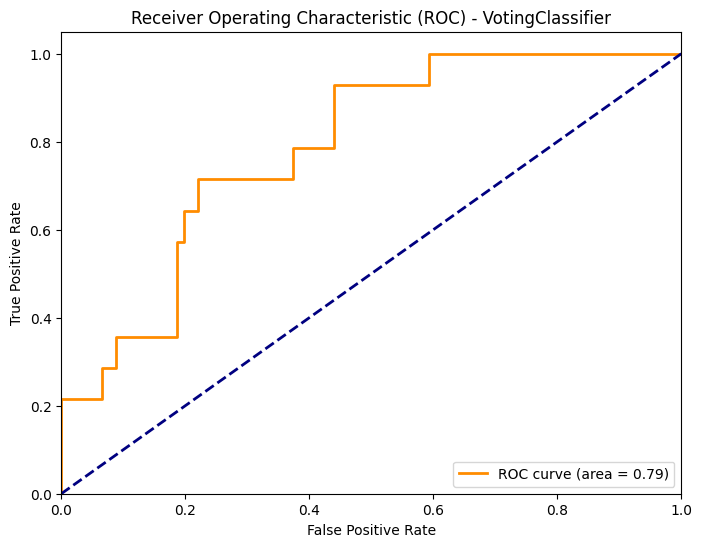

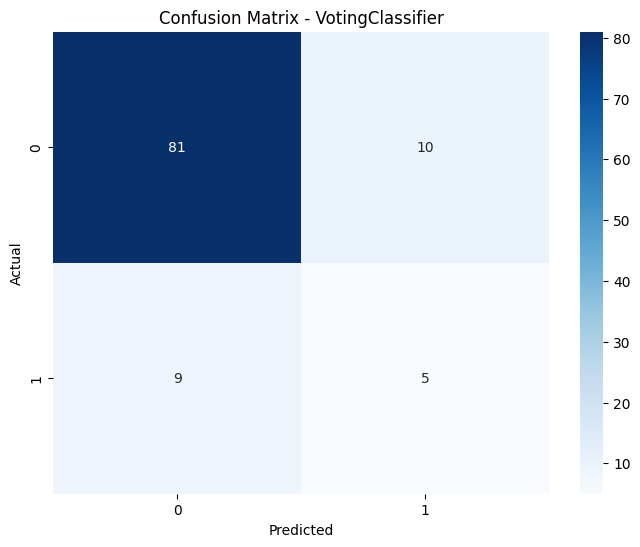

Training Logistic Regression...


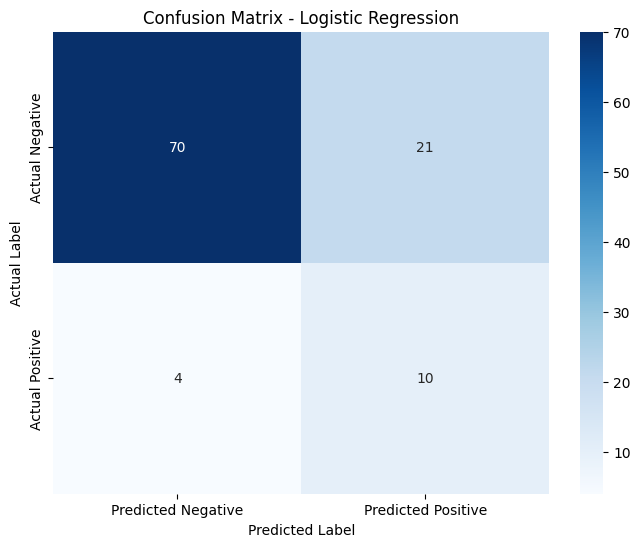

Training Decision Tree...


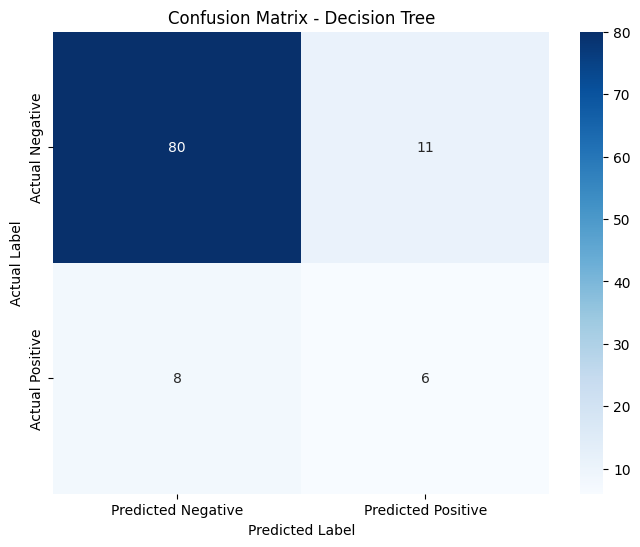

Training Random Forest...


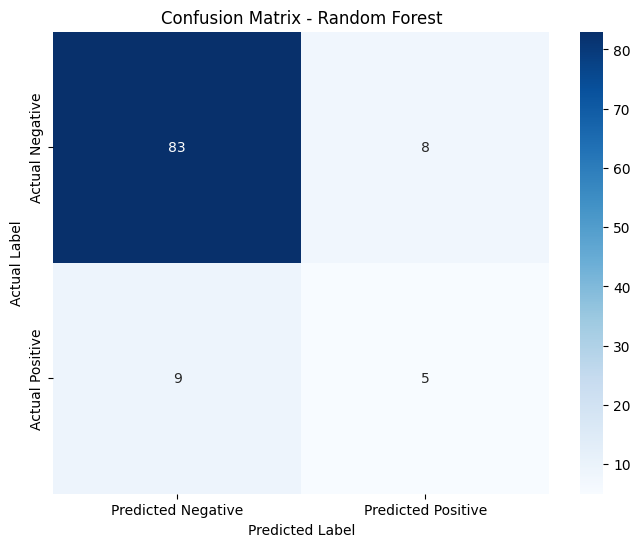

Training SVM...


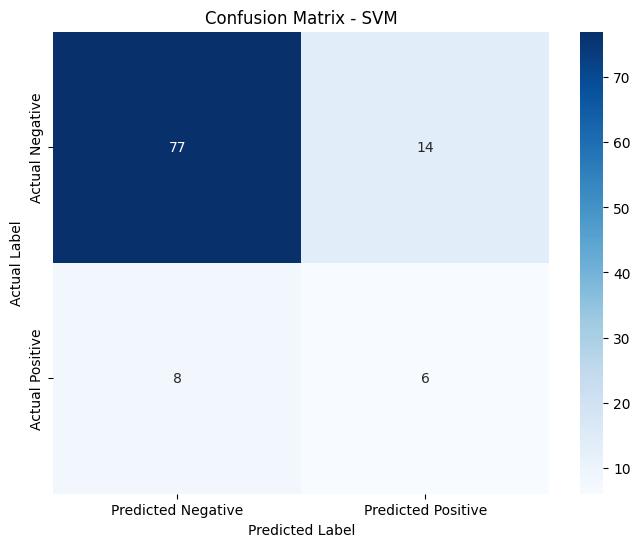

Training K-Nearest Neighbors...


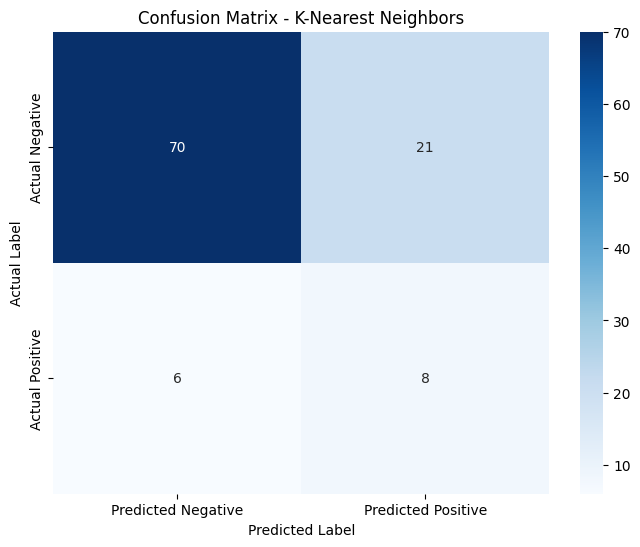

Training XGBoost...


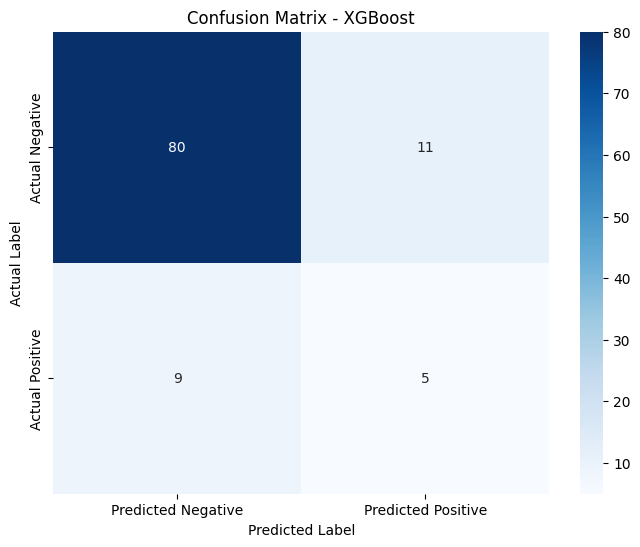

Training LightGBM...


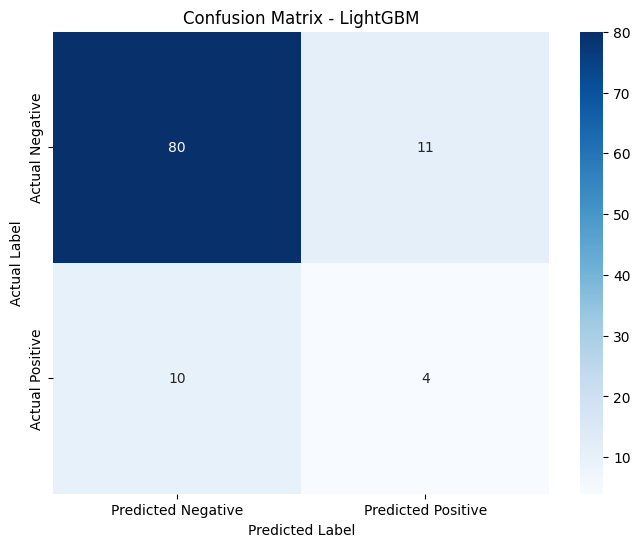

Training MLPClassifier...


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


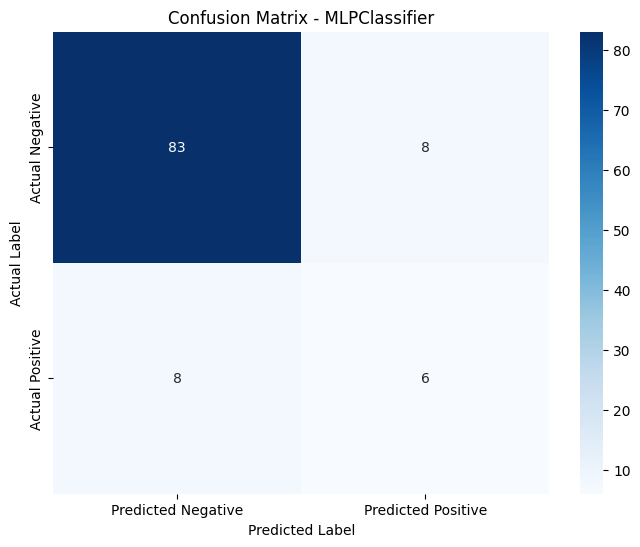

In [ ]:
# --- Visualization and Further Analysis for VotingClassifier ---
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 2. ROC Curve
# Change voting to 'soft' in your ensemble_model definition
ensemble_model = VotingClassifier(estimators=[
    ('lr', LogisticRegression(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('svm', SVC(random_state=42, probability=True)),  # Enable probability for VotingClassifier
    ('rf', RandomForestClassifier(random_state=42)),
    ('knn', KNeighborsClassifier()),
    ('xgb', XGBClassifier(random_state=42)),
    ('lgbm', LGBMClassifier(random_state=42)),
    ('mlp', MLPClassifier(random_state=42, max_iter=500))
], voting='soft')  # Changed to 'soft'

# Apply SMOTE to the original features, not the polynomial features
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Then apply polynomial features to the resampled data
X_train_poly_resampled = poly.fit_transform(X_train_resampled)
X_test_poly = poly.transform(X_test)  # Ensure X_test_poly is also transformed

# Now fit the ensemble model using the resampled polynomial features
ensemble_model.fit(X_train_poly_resampled, y_train_resampled)

y_prob = ensemble_model.predict_proba(X_test_poly)[:, 1]  # Probability of positive class
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - VotingClassifier')
plt.legend(loc="lower right")
plt.show()

# 3. Confusion Matrix
y_pred = ensemble_model.predict(X_test_poly)  # Predictions from VotingClassifier
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - VotingClassifier')
plt.show()

# Feature importance (tree based models )
from sklearn.metrics import confusion_matrix # Import confusion_matrix

models = [
    ('Logistic Regression', LogisticRegression(random_state=42)),
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(random_state=42)),
    ('SVM', SVC(random_state=42)),
    ('K-Nearest Neighbors', KNeighborsClassifier()),
    ('XGBoost', XGBClassifier(random_state=42)),
    ('LightGBM', LGBMClassifier(random_state=42)),
    ('MLPClassifier', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=200)),
    # ... (your VotingClassifier definition) ...
]

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train and evaluate models
for model_name, model in models:
    print(f"Training {model_name}...")

    # Fit the model using resampled data
    model.fit(X_train_resampled, y_train_resampled)

    # Make predictions
    y_pred = model.predict(X_test)

    # ... (your evaluation metrics code) ...

    # Feature Importance (for tree-based models)
    if model_name in ['Random Forest', 'XGBoost', 'LightGBM', 'Decision Tree']:
        # This is where you should add your feature importance code
        # and it should be indented
        # Example:
        # importances = model.feature_importances_
        # print(f"Feature Importances for {model_name}: {importances}")
        pass  # This is a placeholder - replace with your actual feature importance code

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    # Visualize Confusion Matrix with seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=['Predicted Negative', 'Predicted Positive'],
                yticklabels=['Actual Negative', 'Actual Positive'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()


In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# 1. Define individual models
estimator1 = LogisticRegression(random_state=42)
estimator2 = MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500)
estimator3 = DecisionTreeClassifier(random_state=42)
estimator4 = RandomForestClassifier(random_state=42)

# 2. Create the VotingClassifier
ensemble_model = VotingClassifier(
    estimators=[('lr', estimator1), ('mlp', estimator2), ('dt', estimator3), ('rf', estimator4)],
    voting='hard'  # or 'soft'
)

# 3. Train the ensemble model
ensemble_model.fit(X_train, y_train)

# 4. Evaluate the model
y_pred = ensemble_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")
print(classification_report(y_test, y_pred))

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8857142857142857
              precision    recall  f1-score   support

           0       0.89      0.99      0.94        91
           1       0.75      0.21      0.33        14

    accuracy                           0.89       105
   macro avg       0.82      0.60      0.64       105
weighted avg       0.87      0.89      0.86       105



In [ ]:
# 1. Create feature matrix (X) and target variable (y)
X = df[['Patient age quantile', 'Hematocrit', 'Hemoglobin', 'Platelets', 'Leukocytes', 'Lymphocytes', 'Mean platelet volume ', 'Red blood cell distribution width (RDW)']]
y = df['covid_positive']

# 2. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Data scaling (using StandardScaler)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Define your models dictionary with adjustments for MLPClassifier
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),  # Enable probability for SVC
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        random_state=42,
        max_iter=2000,  # Increased max_iter
        learning_rate='adaptive',  # Adaptive learning rate
        learning_rate_init=0.001,  # Initial learning rate
        early_stopping=True,  # Enable early stopping
        validation_fraction=0.1  # Validation set fraction
    )
}

# 5. Fit and calculate ROC AUC scores for each model
roc_auc_scores = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    # Check if the model has predict_proba (for ROC AUC calculation)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]  # Get probabilities for positive class
        roc_auc = roc_auc_score(y_test, y_prob)
        roc_auc_scores.append([model_name, roc_auc])
    else:
        print(f"Skipping ROC AUC calculation for {model_name} as it does not have predict_proba.")

# 6. Print the results in a table
headers = ["Model", "ROC AUC Score"]
print(tabulate(roc_auc_scores, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════════════╕
│ Model               │   ROC AUC Score │
╞═════════════════════╪═════════════════╡
│ Logistic Regression │        0.828885 │
├─────────────────────┼─────────────────┤
│ Decision Tree       │        0.568681 │
├─────────────────────┼─────────────────┤
│ Random Forest       │        0.791994 │
├─────────────────────┼─────────────────┤
│ SVM                 │        0.72606  │
├─────────────────────┼─────────────────┤
│ K-Nearest Neighbors │        0.720565 │
├─────────────────────┼─────────────────┤
│ XGBoost             │        0.758242 │
├─────────────────────┼─────────────────┤
│ LightGBM            │        0.795918 │
├─────────────────────┼─────────────────┤
│ MLPClassifier       │        0.682104 │
╘═════════════════════╧═════════════════╛


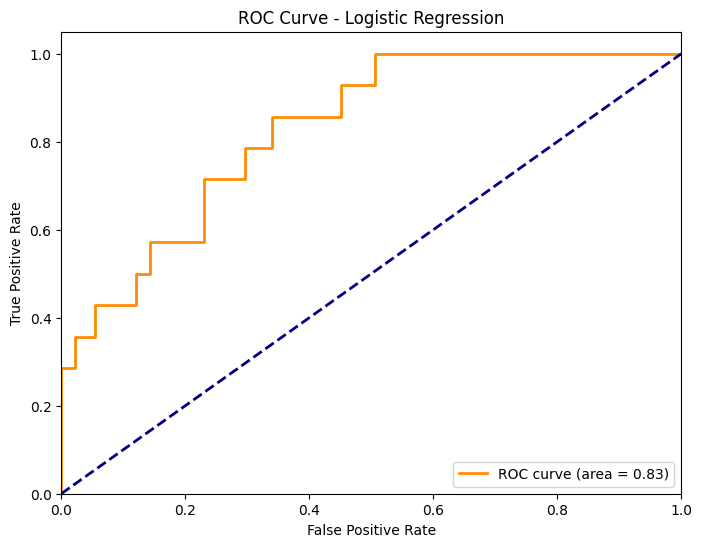

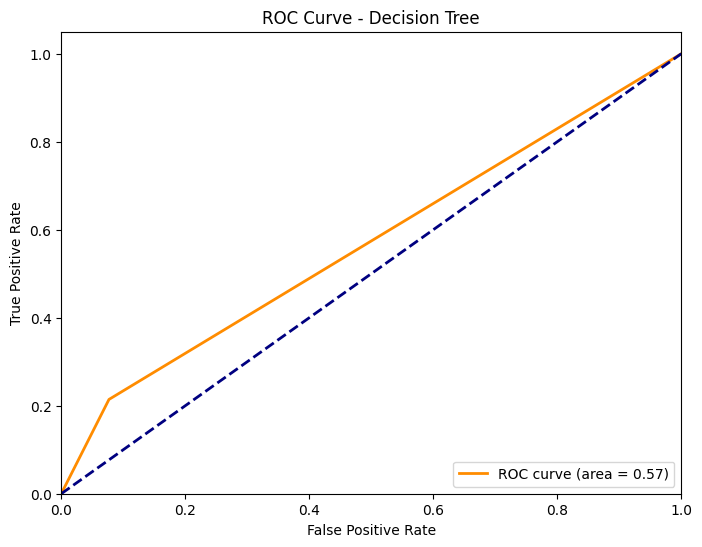

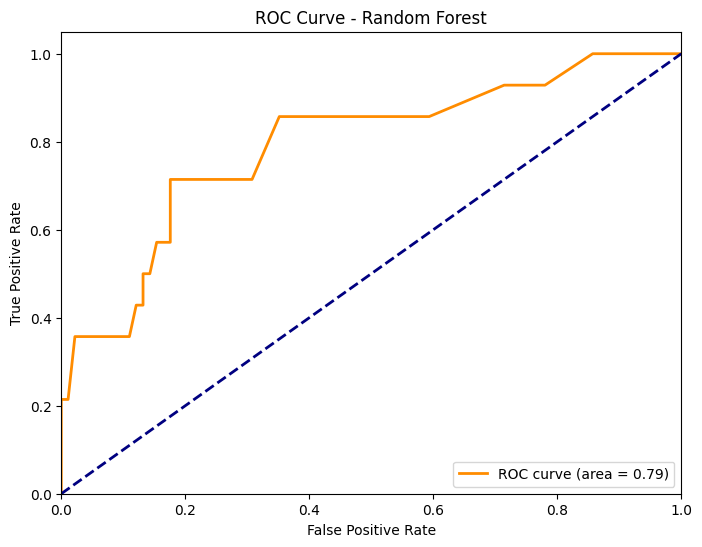

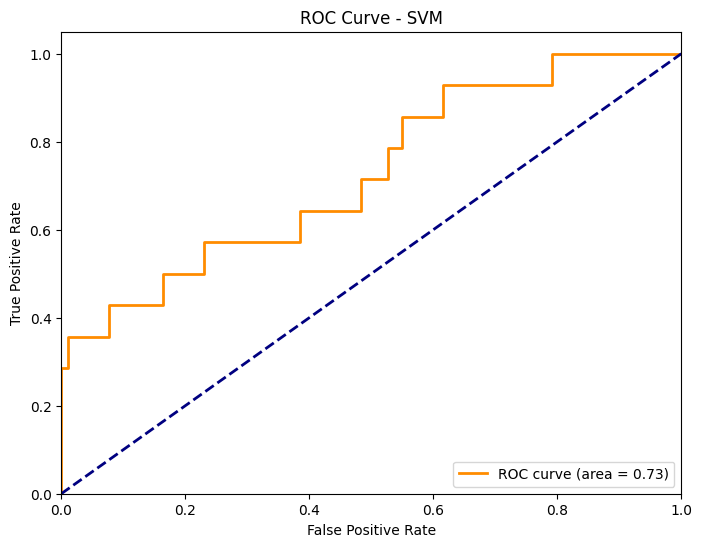

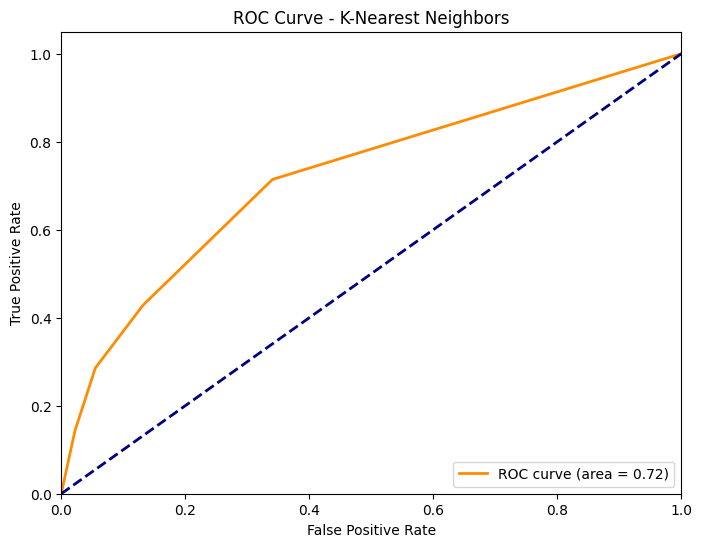

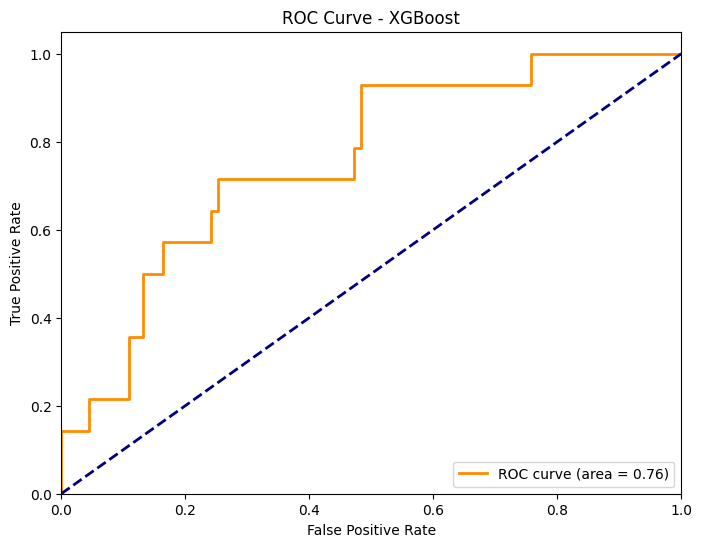

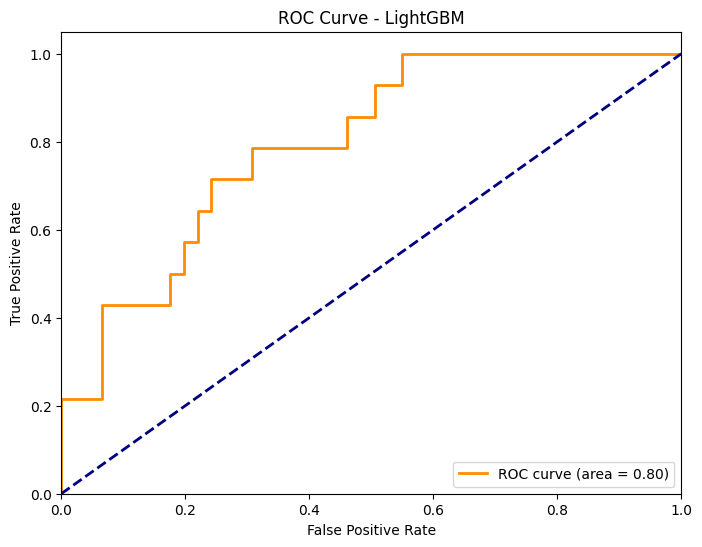

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


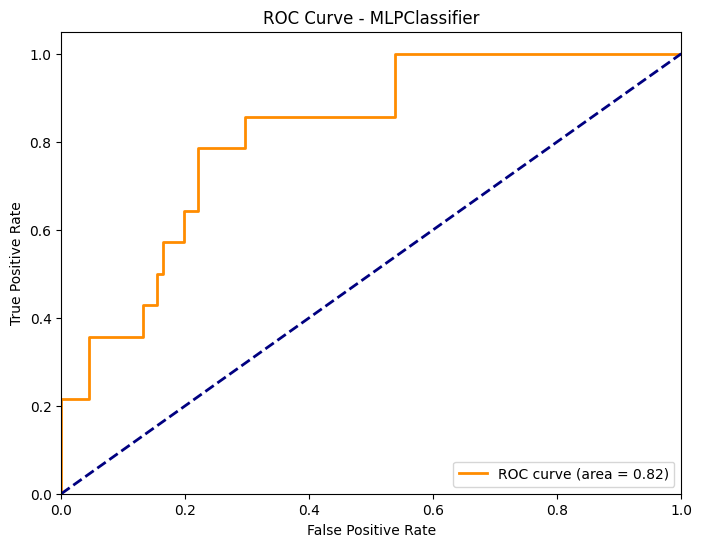

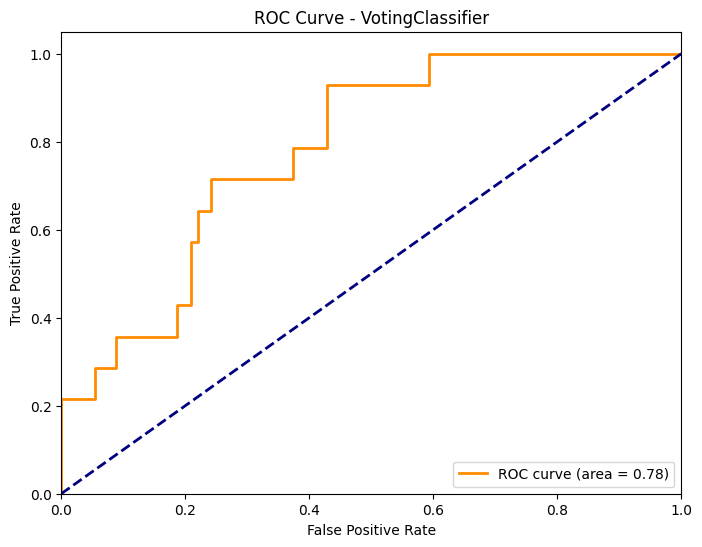

In [ ]:
# Initialize roc_auc_scores if it doesn't exist
if 'roc_auc_scores' not in locals():
    roc_auc_scores = []

# Define your models (make sure this is correct)
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(random_state=42, probability=True),  # Enable probability for SVC
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500),
    # Ensemble model (VotingClassifier) - make sure 'voting' is 'soft' for ROC AUC
    'VotingClassifier': VotingClassifier(estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svm', SVC(random_state=42, probability=True)),  # Enable probability for SVC
        ('rf', RandomForestClassifier(random_state=42)),
        ('knn', KNeighborsClassifier()),
        ('xgb', XGBClassifier(random_state=42)),
        ('lgbm', LGBMClassifier(random_state=42)),
        ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=500))
    ], voting='soft')
}


# Iterate through models and calculate ROC AUC scores
for model_name, model in models.items():
    # Fit the model using appropriate training data
    if not hasattr(model, "classes_"):
        # Use X_train_poly_resampled for VotingClassifier
        training_data = X_train_poly_resampled if model_name == 'VotingClassifier' else X_train
        training_labels = y_train_resampled if model_name == 'VotingClassifier' else y_train
        model.fit(training_data, training_labels)

    # Prepare prediction data (transform if necessary)
    prediction_data = X_test_poly if model_name == 'VotingClassifier' else X_test  # Use X_test_poly for VotingClassifier

    # Get predicted probabilities (for positive class)
    y_prob = model.predict_proba(prediction_data)[:, 1]

    # Calculate ROC curve and AUC
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    roc_auc_scores.append([model_name, roc_auc])  # Store ROC AUC

    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {model_name}')
    plt.legend(loc="lower right")
    plt.show()

In [ ]:
# 2. Define your models dictionary
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', random_state=42, max_iter=1000)
}

# 3. Fit and evaluate individual models (with imputation)
for i, (model_name, model) in enumerate(models.items(), start=1):
    # Impute missing values in X_train before fitting the model
    imputer = SimpleImputer(strategy='mean')
    X_train_imputed = imputer.fit_transform(X_train)

    model.fit(X_train_imputed, y_train)

    # Impute missing values in X_test before making predictions
    X_test_imputed = imputer.transform(X_test)
    y_pred = model.predict(X_test_imputed)

    accuracy = accuracy_score(y_test, y_pred)
    print(f'Model {i} ({model_name}) Test Accuracy: %.3f' % accuracy)

# 4. Define and evaluate the ensemble model
ensemble_model = VotingClassifier(estimators=[(name, model) for name, model in models.items()], voting='hard')
ensemble_model.fit(X_train_imputed, y_train)  # Fit using imputed data

# Predict using imputed data for the ensemble model
y_pred_ensemble = ensemble_model.predict(X_test_imputed)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Ensemble Model Test Accuracy: %.3f' % accuracy_ensemble)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)  # 5-fold cross-validation
print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Cross-validation scores: [0.86842105 0.92105263 0.88596491 0.94736842 0.89380531]
Mean accuracy: 0.9033224654556745


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Define the model dictionary
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'MLPClassifier': MLPClassifier(hidden_layer_sizes=(100, 50),
                                   activation='relu', solver='adam',
                                   random_state=42, max_iter=500)
}

# Train and evaluate each model
for model_name, model in models.items():
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Make predictions
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    print(f"{model_name} Accuracy: {accuracy}")

In [ ]:
y_pred_ensemble = ensemble_model.predict(X_test)
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
print(f'Ensemble Model Test Accuracy: %.3f' % accuracy_ensemble)

Ensemble Model Test Accuracy: 0.974


In [ ]:
# 1. Define base learners and meta-learner
estimators = [
    ('lr', LogisticRegression(random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50),
                          activation='relu', solver='adam',
                          random_state=42, max_iter=500)),
    ('rf', RandomForestClassifier(random_state=42))
]

final_estimator = LogisticRegression(random_state=42)

# 2. Create the stacking classifier
stacking_model = StackingClassifier(estimators=estimators,
                                   final_estimator=final_estimator)

# 3. Train the model
stacking_model.fit(X_train, y_train)
# 4. Make predictions on the test set
y_pred = stacking_model.predict(X_test)
# 5. Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Ensemble Model Test Accuracy: {accuracy:.3f}")

# Print classification report for more detailed evaluation
print(classification_report(y_test, y_pred))

Ensemble Model Test Accuracy: 0.974
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

